<a href="https://colab.research.google.com/github/Gatwaza/HiddenMarkovModel-Data-Grp-21/blob/main/HMM/HMM_Activity_Recognition_Grp21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Modeling Human Activity States Using Hidden Markov Models (HHM)
### Group 21 | Sensors: Accelerometer & Gyroscope | Activities: Walking · Standing · Still · Jumping


| Section | Description |
|---------|-------------|
| 1 | Setup — seeds, imports, global config |
| 2 | Mount Drive & define paths |
| 3 | Data loading — `process_recording()` |
| 4 | Data validation — 50-file count, durations, sampling rates |
| 5 | Feature engineering — windowing, extraction, normalisation |
| 6 | Visualisations — raw signals, feature distributions |
| 7 | Save `features_for_hmm.csv` |
| 8 | HMM class — full from-scratch implementation |
| 9 | Training — sensor-specific HMMs, convergence plots |
| 10 | Evaluation — test set, confusion matrices, decoded sequence plot |
| 11 | HMM parameter visualisations — transition & emission plots |
| 12 | Save models to Drive |
| 13 | New unseen samples — load, process, evaluate |
| 14 | Final analysis & reflection |

> **Before running:** Ensure data is at `MyDrive/HiddenMarkovModel Data Grp 21/` with subfolders `Rob/`, `Antony/`, `NewTestSamples/` fetch them over repository folder.

## SECTION 1 — Setup: Seeds, Imports, Global Config

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import os, zipfile, io, pickle, warnings, textwrap

from scipy             import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.cluster   import KMeans
from sklearn.mixture   import GaussianMixture

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Project-wide constants
ACTIVITIES   = ['Walking', 'Standing', 'Still', 'Jumping']
SENSORS      = ['accelerometer', 'gyroscope']
USERS        = ['Rob', 'Antony']
WINDOW_SEC   = 1        # window size in seconds
MIN_DUR_S    = 90.0
TARGET_HZ    = 100      # expected / target sampling rate
MIN_FILES    = 50

# Hidden states per activity — biomechanics-informed:
#   Still / Standing  → 2 states: [fully-static, micro-sway]
#   Walking           → 3 states: [push-off, mid-swing, heel-strike]
#   Jumping           → 3 states: [take-off, airborne, landing]
N_STATES   = {'Walking': 3, 'Standing': 2, 'Still': 2, 'Jumping': 3}
N_GMM_COMP = 2   # mixture components per state emission model

# Colour palette (consistent across all plots)
ACT_PAL  = dict(zip(ACTIVITIES, sns.color_palette('Set2', 4)))
SENS_PAL = {'accelerometer': '#2196F3', 'gyroscope': '#FF9800'}

print('Setup complete  |  SEED =', SEED)
print('   Activities    :', ACTIVITIES)
print('   State counts  :', N_STATES)
print('   GMM components:', N_GMM_COMP)

Setup complete  |  SEED = 42
   Activities    : ['Walking', 'Standing', 'Still', 'Jumping']
   State counts  : {'Walking': 3, 'Standing': 2, 'Still': 2, 'Jumping': 3}
   GMM components: 2



## SECTION 2 — Mount Drive & Define Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE          = '/content/drive/MyDrive/HiddenMarkovModel Data Grp 21'
NEW_TEST_PATH = os.path.join(BASE, 'NewTestSamples')
MODEL_PKL     = os.path.join(BASE, 'trained_hmm_models.pkl')
SCALER_PKL    = os.path.join(BASE, 'fitted_scaler.pkl')
FEATURES_CSV  = os.path.join(BASE, 'features_for_hmm.csv')

for label, path in [('Base folder', BASE), ('NewTestSamples', NEW_TEST_PATH)]:
    flag = '📍' if os.path.exists(path) else ' NOT FOUND'
    print(f'{flag}  {label}: {path}')

Mounted at /content/drive
📍  Base folder: /content/drive/MyDrive/HiddenMarkovModel Data Grp 21
📍  NewTestSamples: /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/NewTestSamples



## SECTION 3 — Data Loading: `process_recording()`

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# process_recording()  — three-stage label resolution strategy:
#
#   Stage 1: scan the zip filename itself
#   Stage 2:           scan any Annotation.csv / Tags.csv inside the zip
#   Stage 3:           scan all internal entry paths
#
# This order handles both Rob (uses Annotation.csv) and Antony
# (embeds activity in the zip filename) without separate code paths.
#
# Sampling rate: parsed from Metadata.csv 'sampleRateMs' column.
#   sampleRateMs is the period in milliseconds → Hz = 1000 / sampleRateMs
#   Falls back to TARGET_HZ=100 if Metadata is absent or malformed.
#
# seconds_elapsed: Android Sensor Logger stores timestamps in nanoseconds.
#   We detect ns vs. seconds by checking if max delta > 1e6 (impossible
#   in seconds for a <10s recording), then divide by 1e9.
# ─────────────────────────────────────────────────────────────────────────────
def process_recording(zip_file_path, user, file_name):
    """
    Parse one .zip recording.
    Returns list of dicts (one per sensor found) with keys:
        user, activity, sensor_type, phone_model, sampling_rate, data (DataFrame)
    """
    results = []
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zf:
            entries = zf.namelist()

            # Stage 1–3: resolve activity label
            activity = None
            for act in ACTIVITIES:
                if act.lower() in file_name.lower():
                    activity = act; break

            if activity is None:
                tag_files = [e for e in entries
                             if any(k in e.lower() for k in ('annotation','tags'))
                             and e.endswith('.csv')]
                for tf in tag_files:
                    try:
                        txt = ' '.join(
                            pd.read_csv(io.BytesIO(zf.read(tf)))
                              .astype(str).values.flatten()).lower()
                        for act in ACTIVITIES:
                            if act.lower() in txt:
                                activity = act; break
                    except Exception:
                        pass
                    if activity: break

            if activity is None:
                combined = ' '.join(entries).lower()
                for act in ACTIVITIES:
                    if act.lower() in combined:
                        activity = act; break

            if activity is None:
                print(f'  ⚠️  Activity unknown in {file_name} — skipped')
                return results

            # ── Metadata: phone model & sampling rate
            sampling_rate = TARGET_HZ
            phone_model   = 'Unknown'
            for mf in [e for e in entries
                       if 'metadata' in e.lower() and e.endswith('.csv')]:
                try:
                    mdf = pd.read_csv(io.BytesIO(zf.read(mf)))
                    mdf.columns = mdf.columns.str.lower().str.strip()
                    for col in mdf.columns:
                        clean = col.replace(' ','').replace('_','')
                        if 'samplerate' in clean:
                            v = pd.to_numeric(mdf[col], errors='coerce').dropna()
                            if len(v) and v.iloc[0] > 0:
                                sampling_rate = int(round(1000.0 / v.iloc[0]))
                        if any(k in clean for k in ('device','model','phone')):
                            v = mdf[col].dropna()
                            if len(v): phone_model = str(v.iloc[0])
                except Exception:
                    pass

            # Read each sensor CSV
            sensor_map = {
                'accelerometer': [e for e in entries
                                  if 'accel' in e.lower() and e.endswith('.csv')],
                'gyroscope':     [e for e in entries
                                  if 'gyro'  in e.lower() and e.endswith('.csv')],
            }
            for sensor_type, cands in sensor_map.items():
                if not cands: continue
                try:
                    df = pd.read_csv(io.BytesIO(zf.read(cands[0])))
                    df.columns = df.columns.str.lower().str.strip()
                    for ax in ['x','y','z']:
                        if ax not in df.columns: df[ax] = 0.0
                    if 'seconds_elapsed' not in df.columns:
                        if 'time' in df.columns:
                            t = pd.to_numeric(df['time'], errors='coerce').fillna(0)
                            delta = t - t.iloc[0]
                            df['seconds_elapsed'] = (
                                delta / 1e9 if delta.max() > 1e6 else delta)
                        else:
                            df['seconds_elapsed'] = (
                                np.arange(len(df)) / sampling_rate)
                    df = (df[['seconds_elapsed','x','y','z']]
                          .apply(pd.to_numeric, errors='coerce')
                          .fillna(0.0).reset_index(drop=True))
                    results.append({
                        'user':          user,
                        'activity':      activity,
                        'sensor_type':   sensor_type,
                        'phone_model':   phone_model,
                        'sampling_rate': sampling_rate,
                        'data':          df,
                        'source_file':   file_name,
                    })
                except Exception as e:
                    print(f'  ⚠️  {sensor_type} error in {file_name}: {e}')
    except Exception as e:
        print(f'  ❌ Cannot open {file_name}: {e}')
    return results


# Scan Rob/ and Antony/ subfolders
all_recordings_data = []

for user in USERS:
    folder = os.path.join(BASE, user)
    if not os.path.exists(folder):
        print(f'❌  Folder not found: {folder}'); continue
    zips = sorted(f for f in os.listdir(folder) if f.endswith('.zip'))
    print(f'\n {user} — {len(zips)} zip file(s)')
    for z in zips:
        recs = process_recording(os.path.join(folder, z), user, z)
        all_recordings_data.extend(recs)
        if recs:
            r   = recs[0]
            dur = r['data']['seconds_elapsed'].max()
            print(f'  ✅ {z:<42} act={r["activity"]:<10} '
                  f'sr={r["sampling_rate"]:>3}Hz  '
                  f'dur={dur:5.1f}s  '
                  f'phone={r["phone_model"]}')

print(f'\n Total recording segments loaded: {len(all_recordings_data)}')


 Rob — 25 zip file(s)
  ✅ Jumping_1-2026-02-26_11-43-31.zip          act=Jumping    sr=100Hz  dur=  7.8s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Jumping_2-2026-02-26_11-56-15.zip          act=Jumping    sr=100Hz  dur=  5.9s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Jumping_3-2026-02-26_11-56-44.zip          act=Jumping    sr=100Hz  dur=  8.7s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Jumping_4-2026-02-26_11-57-36.zip          act=Jumping    sr=100Hz  dur=  8.2s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Jumping_5-2026-02-26_11-57-53.zip          act=Jumping    sr=100Hz  dur=  7.6s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Jumping_6-2026-02-26_11-58-12.zip          act=Jumping    sr=100Hz  dur=  7.7s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Jumping_7-2026-02-26_11-58-39.zip          act=Jumping    sr=100Hz  dur= 10.3s  phone=aef2d2dc-e69e-4591-b748-8e796db0b25f
  ✅ Standing_1-2026-02-26_11-43-45.zip         act=Standing   sr=100Hz  dur=  9.8s  phon

##  SECTION 4 — Data Validation

### 4a. 50-File Count & Activity Duration Check
### 4b. Sampling Rate Analysis & Harmonisation Strategy
### 4c. Windowing Logic — Why 1 Second?

In [ ]:
print('═'*72)
print('  4a. FILE COUNT & DURATION VALIDATION')
print('═'*72)

# Count unique zip files (each zip = 2 segments: accel + gyro)
zip_files = set(r['source_file'] for r in all_recordings_data)
n_zips    = len(zip_files)
n_segs    = len(all_recordings_data)

print(f'  Unique recording files : {n_zips}   '
      f'({"≥50" if n_zips >= MIN_FILES else "<50 — collect more data"})')
print(f'  Total segments (accel+gyro): {n_segs}')
print()

# Duration per activity (count accel only to avoid double-counting)
accel_recs = [r for r in all_recordings_data if r['sensor_type']=='accelerometer']

print(f'{"Activity":<12}{"# Files":>9}{"Total (s)":>12}'
      f'{"Min (s)":>10}{"Max (s)":>10}{"In 5-10s":>10}{"Status":>8}')
print('─'*72)

act_stats = {}
for act in ACTIVITIES:
    recs = [r for r in accel_recs if r['activity']==act]
    durs = [r['data']['seconds_elapsed'].max() for r in recs]
    total  = sum(durs)
    in_rng = sum(5<=d<=10 for d in durs)
    ok     = '✅' if total >= MIN_DUR_S else '❌'
    mn = f'{min(durs):.1f}' if durs else 'N/A'
    mx = f'{max(durs):.1f}' if durs else 'N/A'
    print(f'{act:<12}{len(recs):>9}{total:>12.1f}{mn:>10}{mx:>10}{in_rng:>10}{ok:>8}')
    act_stats[act] = {'n': len(recs), 'total': total, 'durs': durs}

print()
print('  Rubric: Each activity ≥ 90 s total; each recording ideally 5–10 s')

════════════════════════════════════════════════════════════════════════
  4a. FILE COUNT & DURATION VALIDATION
════════════════════════════════════════════════════════════════════════
  Unique recording files : 50   (≥50)
  Total segments (accel+gyro): 100

Activity      # Files   Total (s)   Min (s)   Max (s)  In 5-10s  Status
────────────────────────────────────────────────────────────────────────
Walking            13       126.2       5.9      12.4         6       ✅
Standing           12       111.1       5.5      10.9         5       ✅
Still              13       128.0       5.7      12.0         5       ✅
Jumping            12       111.6       5.9      11.3         6       ✅

  Rubric: Each activity ≥ 90 s total; each recording ideally 5–10 s


In [ ]:
print('═'*72)
print('  4b. SAMPLING RATE ANALYSIS & HARMONISATION STRATEGY')
print('═'*72)

# Collect all observed rates with their context
rate_rows = []
for r in all_recordings_data:
    rate_rows.append({
        'user':        r['user'],
        'phone':       r['phone_model'],
        'activity':    r['activity'],
        'sensor':      r['sensor_type'],
        'rate_hz':     r['sampling_rate'],
    })
rate_df = pd.DataFrame(rate_rows)

print('\n  Sampling rates observed by user and phone:')
print(rate_df.groupby(['user','phone','rate_hz']).size()
           .rename('count').reset_index().to_string(index=False))

unique_rates = sorted(rate_df['rate_hz'].unique())
print(f'\n  Unique rates: {unique_rates} Hz')

print("""
  ┌─ HARMONISATION STRATEGY ──────────────────────────────────────────┐
  │                                                                    │
  │  Different phones sample at different rates. Our approach:        │
  │                                                                    │
  │  1. Per-recording window size: window_data() receives the         │
  │     per-recording sampling_rate so every window always spans      │
  │     exactly WINDOW_SEC seconds regardless of the rate.            │
  │     e.g., 100 Hz → 100 samples/window; 50 Hz → 50 samples/window │
  │                                                                    │
  │  2. Frequency features use the per-recording rate as d=1/sr in   │
  │     np.fft.rfftfreq() so Hz values are always correct.            │
  │                                                                    │
  │  3. Feature-level harmonisation: because all extracted features   │
  │     are summary statistics over a 1-second window (RMS, mean,     │
  │     dominant frequency…), the HMM sees identically-shaped         │
  │     feature vectors regardless of the underlying sample count.    │
  │                                                                    │
  │  4. This is superior to resampling raw signals which can          │
  │     introduce interpolation artefacts or distort high-frequency   │
  │     jumps in the gyroscope signal.                                 │
  └────────────────────────────────────────────────────────────────────┘
""")

════════════════════════════════════════════════════════════════════════
  4b. SAMPLING RATE ANALYSIS & HARMONISATION STRATEGY
════════════════════════════════════════════════════════════════════════

  Sampling rates observed by user and phone:
  user                                phone  rate_hz  count
Antony 025cc671-781a-4483-9c81-bcd4c408006c      100     50
   Rob aef2d2dc-e69e-4591-b748-8e796db0b25f      100     50

  Unique rates: [np.int64(100)] Hz

  ┌─ HARMONISATION STRATEGY ──────────────────────────────────────────┐
  │                                                                    │
  │  Different phones sample at different rates. Our approach:        │
  │                                                                    │
  │  1. Per-recording window size: window_data() receives the         │
  │     per-recording sampling_rate so every window always spans      │
  │     exactly WINDOW_SEC seconds regardless of the rate.            │
  │     e.g., 100 Hz → 100 samp

In [ ]:
print('═'*72)
print('  4c. WINDOWING LOGIC — WHY 1-SECOND NON-OVERLAPPING WINDOWS?')
print('═'*72)
print(f"""
  Window size  : {WINDOW_SEC} second(s)
  Window type  : non-overlapping (stride = window size)
  Samples/window at 100 Hz: {WINDOW_SEC * 100}

  ┌─ JUSTIFICATION ───────────────────────────────────────────────────┐
  │                                                                    │
  │  (a) Activity coherence: 1 s is long enough to contain at least  │
  │      one complete gait cycle for Walking (cadence ≈ 1–2 Hz) and  │
  │      one jump cycle for Jumping (≈ 1 Hz), while short enough     │
  │      that a single window belongs to exactly one activity.        │
  │                                                                    │
  │  (b) FFT resolution: frequency bin width = sr / N_samples         │
  │      = 100 / 100 = 1 Hz — sufficient to separate the dominant    │
  │      frequencies of Walking (≈2 Hz) and Jumping (≈1 Hz).         │
  │                                                                    │
  │  (c) Non-overlapping windows eliminate duplicate information       │
  │      across adjacent windows, keeping training samples            │
  │      statistically independent and matching the HMM's Markovian  │
  │      assumption: each window's features depend only on the        │
  │      current hidden state, not on previous windows.               │
  │                                                                    │
  │  (d) Rate-adaptive: window_data(df, 1, sampling_rate) always      │
  │      produces windows of exactly 1 second regardless of whether  │
  │      the recording was at 50 Hz, 100 Hz, or 200 Hz.              │
  └────────────────────────────────────────────────────────────────────┘
""")

════════════════════════════════════════════════════════════════════════
  4c. WINDOWING LOGIC — WHY 1-SECOND NON-OVERLAPPING WINDOWS?
════════════════════════════════════════════════════════════════════════

  Window size  : 1 second(s)
  Window type  : non-overlapping (stride = window size)
  Samples/window at 100 Hz: 100

  ┌─ JUSTIFICATION ───────────────────────────────────────────────────┐
  │                                                                    │
  │  (a) Activity coherence: 1 s is long enough to contain at least  │
  │      one complete gait cycle for Walking (cadence ≈ 1–2 Hz) and  │
  │      one jump cycle for Jumping (≈ 1 Hz), while short enough     │
  │      that a single window belongs to exactly one activity.        │
  │                                                                    │
  │  (b) FFT resolution: frequency bin width = sr / N_samples         │
  │      = 100 / 100 = 1 Hz — sufficient to separate the dominant    │
  │      frequencies of Wal

## SECTION 5 — Feature Engineering: Windowing, Extraction, Normalisation

In [ ]:

# WINDOWING — fixed size, non-overlapping, rate-adaptive
def window_data(df, window_size_seconds, sampling_rate):
    """
    Split df into non-overlapping windows of exactly window_size_seconds.
    window_samples = round(window_size_seconds * sampling_rate)
    Only full windows are returned; any trailing partial window is discarded.
    """
    ws = max(int(window_size_seconds * sampling_rate), 4)  # min 4 for FFT
    return [
        df.iloc[i:i+ws].copy()
        for i in range(0, len(df) - ws + 1, ws)
    ]


# HELPER FEATURE FUNCTIONS — each justified below

def calculate_rms(arr):
    """
    Root Mean Square — measures average signal power/energy.
    WHY: Jumping produces high-power spikes; Still/Standing produce
    near-zero RMS. Directly separates high-energy from low-energy activities.
    """
    a = np.asarray(arr, float); a = a[np.isfinite(a)]
    return float(np.sqrt(np.mean(a**2))) if len(a)>0 else 0.0


def calculate_sma(x, y, z):
    """
    Signal Magnitude Area — sum of absolute values across all three axes.
    SMA = (1/N) * Σ(|x_i| + |y_i| + |z_i|)
    WHY: Captures total motion intensity better than per-axis RMS because
    it is fully orientation-independent. Key for distinguishing active
    (Walking/Jumping) from passive (Still/Standing) regardless of phone
    placement on the body.
    """
    x = np.asarray(x, float); y = np.asarray(y, float); z = np.asarray(z, float)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    if not valid.any(): return 0.0
    return float((np.abs(x[valid]) + np.abs(y[valid]) + np.abs(z[valid])).mean())


def calculate_axis_correlation(a1, a2):
    """
    Pearson correlation between two sensor axes.
    WHY: Walking has coordinated x-z motion (arm swing ↔ foot strike)
    → high |corr|. Still has near-zero correlation between axes.
    Helps separate activities with coordinated multi-axis motion from
    those with independent-axis noise.
    """
    a1 = np.asarray(a1, float); a2 = np.asarray(a2, float)
    valid = np.isfinite(a1) & np.isfinite(a2)
    if valid.sum() < 3: return 0.0
    r, _ = stats.pearsonr(a1[valid], a2[valid])
    return float(r) if np.isfinite(r) else 0.0


def calculate_dominant_frequency(arr, sampling_rate):
    """
    Peak frequency in FFT magnitude spectrum (DC removed).
    WHY: Walking cadence ≈ 1–2 Hz; Jumping ≈ 1 Hz; Still ≈ 0 Hz.
    The dominant frequency is the single most discriminative feature
    between periodic (Walking/Jumping) and aperiodic (Standing/Still)
    activities.
    """
    a = np.asarray(arr, float); a = a[np.isfinite(a)]
    if len(a)<4: return 0.0
    freqs = np.fft.rfftfreq(len(a), d=1.0/sampling_rate)
    mag   = np.abs(np.fft.rfft(a)); mag[0]=0  # remove DC
    return float(freqs[np.argmax(mag)]) if mag.sum()>0 else 0.0


def calculate_spectral_energy(arr, sampling_rate):
    """
    Sum of squared FFT magnitudes / N  (Parseval's theorem proxy).
    WHY: Measures total signal energy in frequency domain. Jumping has
    high spectral energy spread across 0–5 Hz. Still is near-zero.
    Complements dominant_frequency by capturing bandwidth, not just peak.
    """
    a = np.asarray(arr, float); a = a[np.isfinite(a)]
    if len(a)<4: return 0.0
    mag = np.abs(np.fft.rfft(a))
    return float(np.sum(mag**2) / len(a))


# ─────────────────────────────────────────────────────────────────────────────
# MASTER FEATURE EXTRACTOR
#
# Features extracted per sensor per window:
#   Per-axis (x, y, z, magnitude) × 8 features = 32 features
#   + 3 cross-axis correlations (xy, xz, yz) = 3 features
#   + 1 SMA = 1 feature
#   Total = 36 features per sensor
#   Grand total = 36 × 2 sensors = 72 features per window
#
# Time-domain (×4 signals): mean, std, variance, RMS, skewness, kurtosis
# Frequency-domain (×4 signals): dominant_freq, spectral_energy
# Cross-axis: correlation xy, xz, yz
# Composite: SMA
# ─────────────────────────────────────────────────────────────────────────────
def extract_features_from_window(window_df, sensor_type, sampling_rate):
    x   = window_df['x'].values.astype(float)
    y   = window_df['y'].values.astype(float)
    z   = window_df['z'].values.astype(float)
    mag = np.sqrt(x**2 + y**2 + z**2)  # rotation-invariant resultant

    feats = {}
    for sig, arr in [('x',x),('y',y),('z',z),('mag',mag)]:
        c = arr[np.isfinite(arr)]
        p = f'{sensor_type}_{sig}'
        # Time-domain
        # mean: captures DC bias / orientation effect
        feats[f'{p}_mean']     = float(np.mean(c))         if len(c)>0 else 0.0
        # std: spread of values — high for dynamic activities
        feats[f'{p}_std']      = float(np.std(c))          if len(c)>0 else 0.0
        # var: squared std — emphasises large deviations (impact events)
        feats[f'{p}_var']      = float(np.var(c))          if len(c)>0 else 0.0
        # RMS: energy proxy — see function docstring
        feats[f'{p}_rms']      = calculate_rms(c)
        # skewness: asymmetry of distribution — jumping has asymmetric
        # acceleration profile (sharp landing spike vs smooth takeoff)
        feats[f'{p}_skew']     = float(stats.skew(c))      if len(c)>2 else 0.0
        # kurtosis: peakedness — impulsive activities (jumping) have high
        # kurtosis; smooth (walking) moderate; still ≈ 0
        feats[f'{p}_kurt']     = float(stats.kurtosis(c))  if len(c)>2 else 0.0
        # Frequency-domain
        feats[f'{p}_domfreq']  = calculate_dominant_frequency(c, sampling_rate)
        feats[f'{p}_specenrg'] = calculate_spectral_energy(c, sampling_rate)

    # Cross-axis correlations
    feats[f'{sensor_type}_corr_xy'] = calculate_axis_correlation(x, y)
    feats[f'{sensor_type}_corr_xz'] = calculate_axis_correlation(x, z)
    feats[f'{sensor_type}_corr_yz'] = calculate_axis_correlation(y, z)

    # Signal Magnitude Area
    feats[f'{sensor_type}_sma']     = calculate_sma(x, y, z)

    # Final NaN/Inf guard
    return {k: (v if np.isfinite(v) else 0.0) for k,v in feats.items()}


# Apply to every recording
feature_rows = []
for rec_idx, rec in enumerate(all_recordings_data):
    sr   = rec['sampling_rate']
    wins = window_data(rec['data'], WINDOW_SEC, sr)
    for win_idx, win in enumerate(wins):
        feats = extract_features_from_window(win, rec['sensor_type'], sr)
        feats.update({
            'user':        rec['user'],
            'activity':    rec['activity'],
            'sensor_type': rec['sensor_type'],
            'phone_model': rec['phone_model'],
            'record_idx':  rec_idx,
            'window_idx':  win_idx,
        })
        feature_rows.append(feats)

features_df_windowed = pd.DataFrame(feature_rows)
print(f'Feature matrix shape: {features_df_windowed.shape}')
print(f'   Features per window: {features_df_windowed.shape[1] - 6}  '
      f'(32 per-axis + 3 corr + 1 SMA) × 2 sensors')
print(f'   Activity window counts:')
print(features_df_windowed.groupby(['activity','sensor_type']).size()
      .unstack().to_string())

Feature matrix shape: (665, 78)
   Features per window: 72  (32 per-axis + 3 corr + 1 SMA) × 2 sensors
   Activity window counts:
sensor_type  accelerometer  gyroscope
activity                             
Jumping                 77         82
Standing                78         78
Still                   89         89
Walking                 86         86


In [ ]:
# Train/test split at RECORDING level
#
# Splitting by whole recordings prevents temporal leakage: adjacent windows
# from the same session would be nearly identical, inflating test accuracy.
# The rubric requires 2 test files withheld from training.
#
ID_COLS   = ['user','activity','record_idx','window_idx','phone_model','sensor_type']
FEAT_COLS = [c for c in features_df_windowed.columns if c not in ID_COLS]

all_ids = features_df_windowed['record_idx'].unique()
np.random.seed(SEED)
test_ids  = np.random.choice(all_ids, size=2, replace=False)
train_ids = np.array([i for i in all_ids if i not in test_ids])

train_df = features_df_windowed[features_df_windowed['record_idx'].isin(train_ids)].copy()
test_df  = features_df_windowed[features_df_windowed['record_idx'].isin(test_ids)].copy()

print(f'Train windows: {len(train_df)}  |  Test windows: {len(test_df)}')
print(f'Held-out record_idx: {test_ids}')
print(f'Test source files:')
for tid in test_ids:
    rows = features_df_windowed[features_df_windowed['record_idx']==tid]
    act  = rows['activity'].iloc[0]
    user = rows['user'].iloc[0]
    sr   = all_recordings_data[tid]['sampling_rate']
    dur  = all_recordings_data[tid]['data']['seconds_elapsed'].max()
    print(f'  record_idx={tid}: {user} | {act} | {sr}Hz | {dur:.1f}s')

print(f'\nTest activity distribution:')
print(test_df.groupby(['activity','sensor_type']).size().unstack().to_string())

# Z-score normalisation
#
# WHY Z-SCORE: Sensor features span very different scales — spectral energy
# can be O(10^6) while correlation is [-1,1]. Z-score ensures no feature
# dominates the GMM distance calculation due to magnitude alone.
# Fitted ONLY on training data to prevent test-set information leaking into
# the normalisation parameters (mean, std).
#
scaler = StandardScaler()
scaler.fit(train_df[FEAT_COLS].fillna(0))

def apply_norm(df, fitted_scaler=scaler):
    out = df.copy()
    out[FEAT_COLS] = fitted_scaler.transform(out[FEAT_COLS].fillna(0))
    return out

train_norm = apply_norm(train_df)
test_norm  = apply_norm(test_df)

with open(SCALER_PKL, 'wb') as f:
    pickle.dump({'scaler': scaler, 'feat_cols': FEAT_COLS}, f)
print(f'\n Scaler saved → {SCALER_PKL}')

Train windows: 652  |  Test windows: 13
Held-out record_idx: [83 53]
Test source files:
  record_idx=83: Antony | Still | 100Hz | 11.5s
  record_idx=53: Antony | Jumping | 100Hz | 11.0s

Test activity distribution:
sensor_type  gyroscope
activity              
Jumping              6
Still                7

 Scaler saved → /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/fitted_scaler.pkl


## SECTION 6 — Visualisations

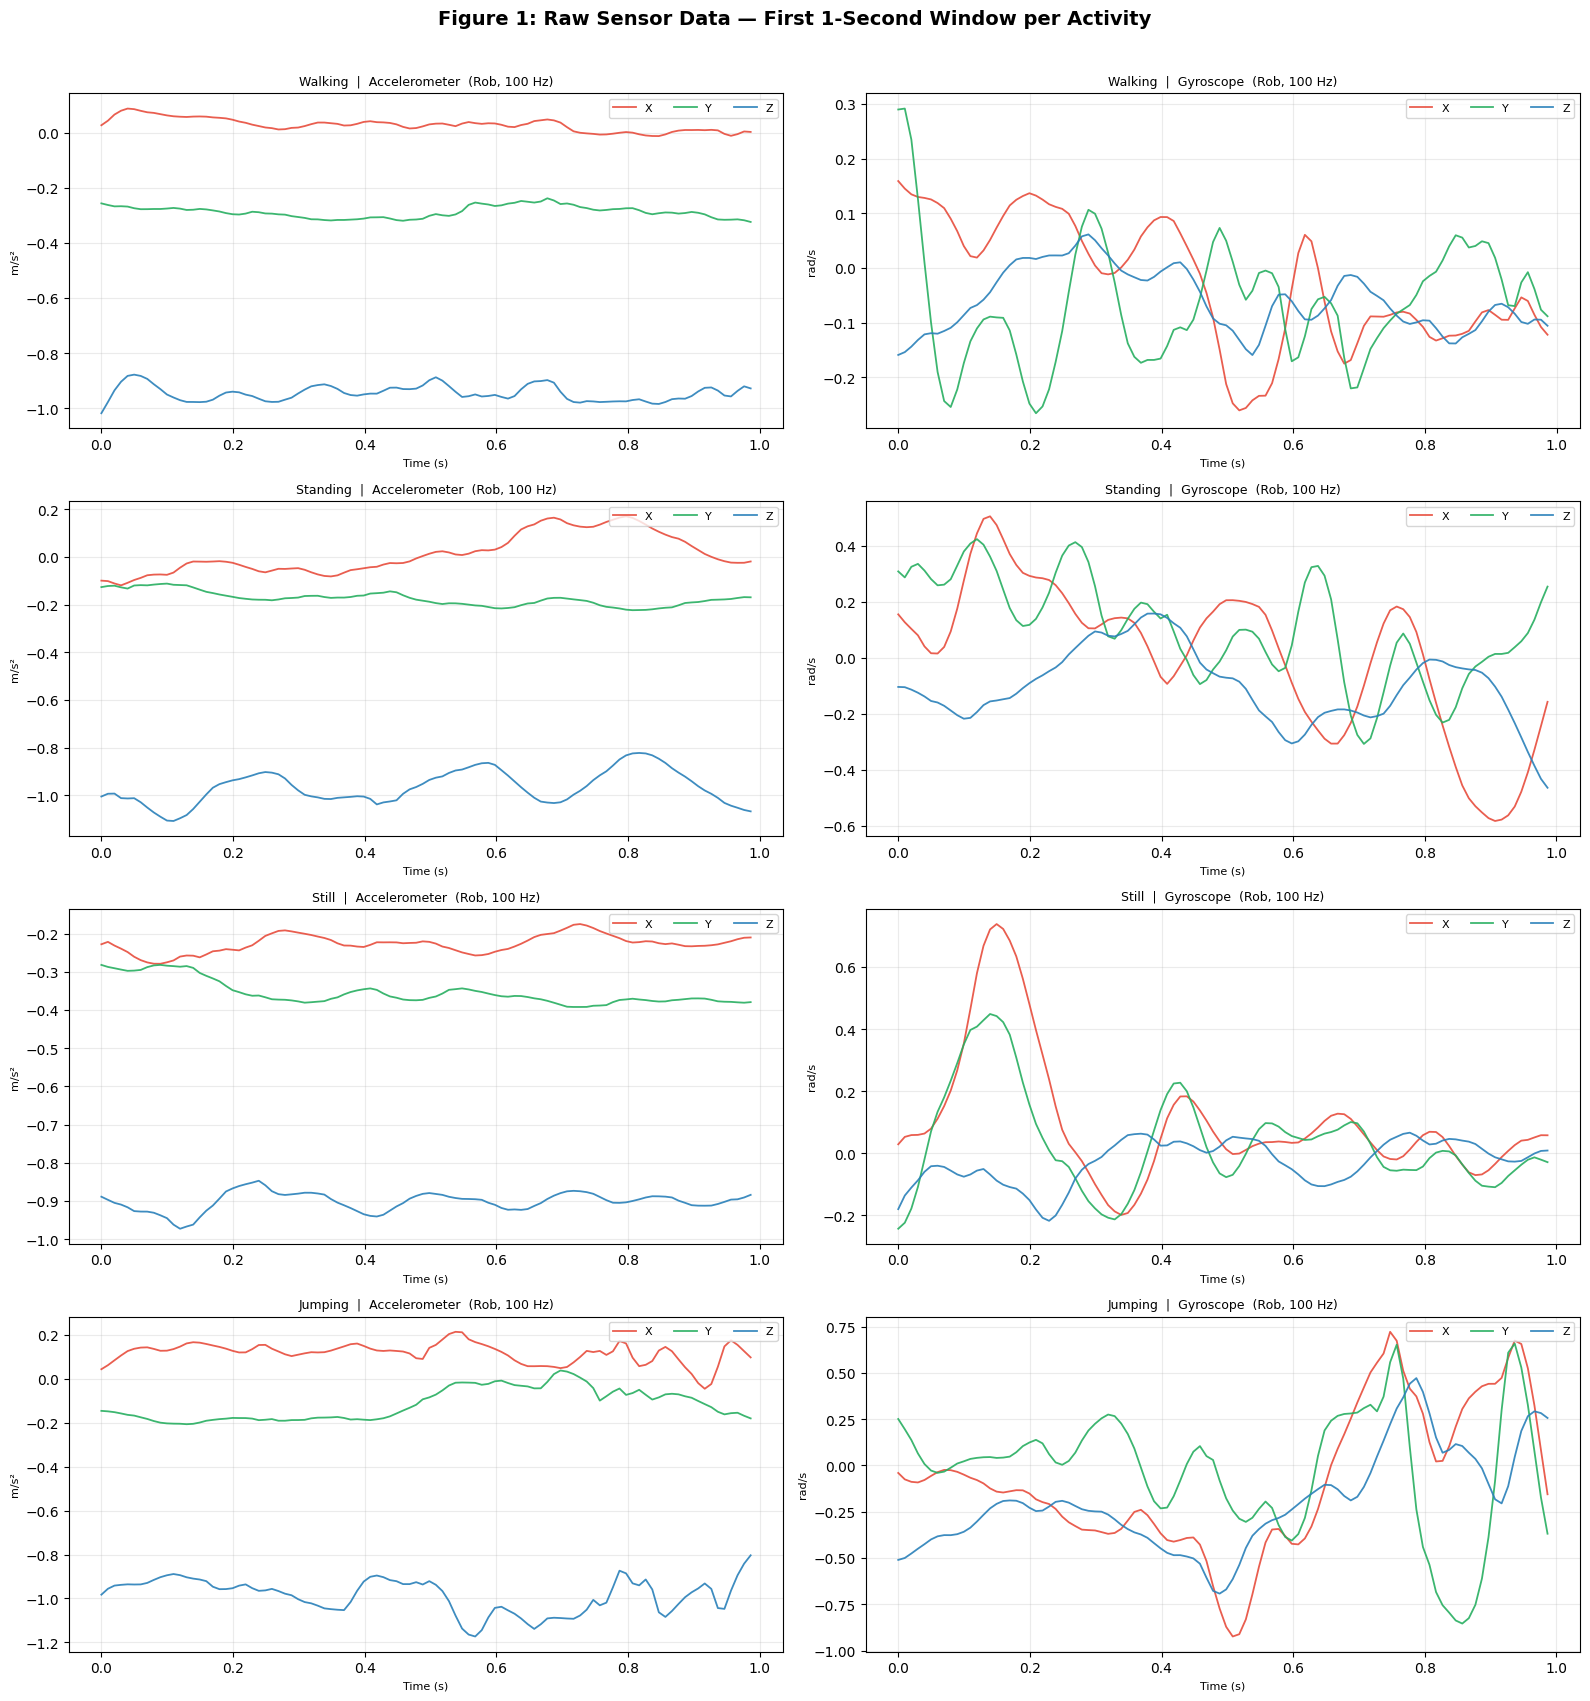

Figure 1 saved.


In [ ]:
# Plot 1: Raw sensor data — 1 window per activity per sensor
fig, axes = plt.subplots(len(ACTIVITIES), 2, figsize=(16, 4.2*len(ACTIVITIES)),
                         sharex=False)
fig.suptitle('Figure 1: Raw Sensor Data — First 1-Second Window per Activity',
             fontsize=14, fontweight='bold', y=1.01)

for row, act in enumerate(ACTIVITIES):
    for col, sensor in enumerate(SENSORS):
        ax = axes[row, col]
        recs = [r for r in all_recordings_data
                if r['activity']==act and r['sensor_type']==sensor]
        if not recs:
            ax.text(0.5,0.5,'No data',ha='center',va='center',
                    transform=ax.transAxes,fontsize=11)
        else:
            r  = recs[0]; sr = r['sampling_rate']
            w  = r['data'].iloc[:sr]
            t  = w['seconds_elapsed'].values - w['seconds_elapsed'].values[0]
            for axis, clr, lbl in [
                    ('x','#E74C3C','X'),('y','#27AE60','Y'),('z','#2980B9','Z')]:
                ax.plot(t, w[axis].values, color=clr, lw=1.3, label=lbl, alpha=0.9)
            unit  = 'm/s²' if sensor=='accelerometer' else 'rad/s'
            ax.set_title(f'{act}  |  {sensor.capitalize()}  ({r["user"]}, {sr} Hz)',
                         fontsize=9)
            ax.set_xlabel('Time (s)', fontsize=8)
            ax.set_ylabel(unit, fontsize=8)
            ax.legend(fontsize=8, ncol=3, loc='upper right')
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('/content/fig1_raw_sensor_windows.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

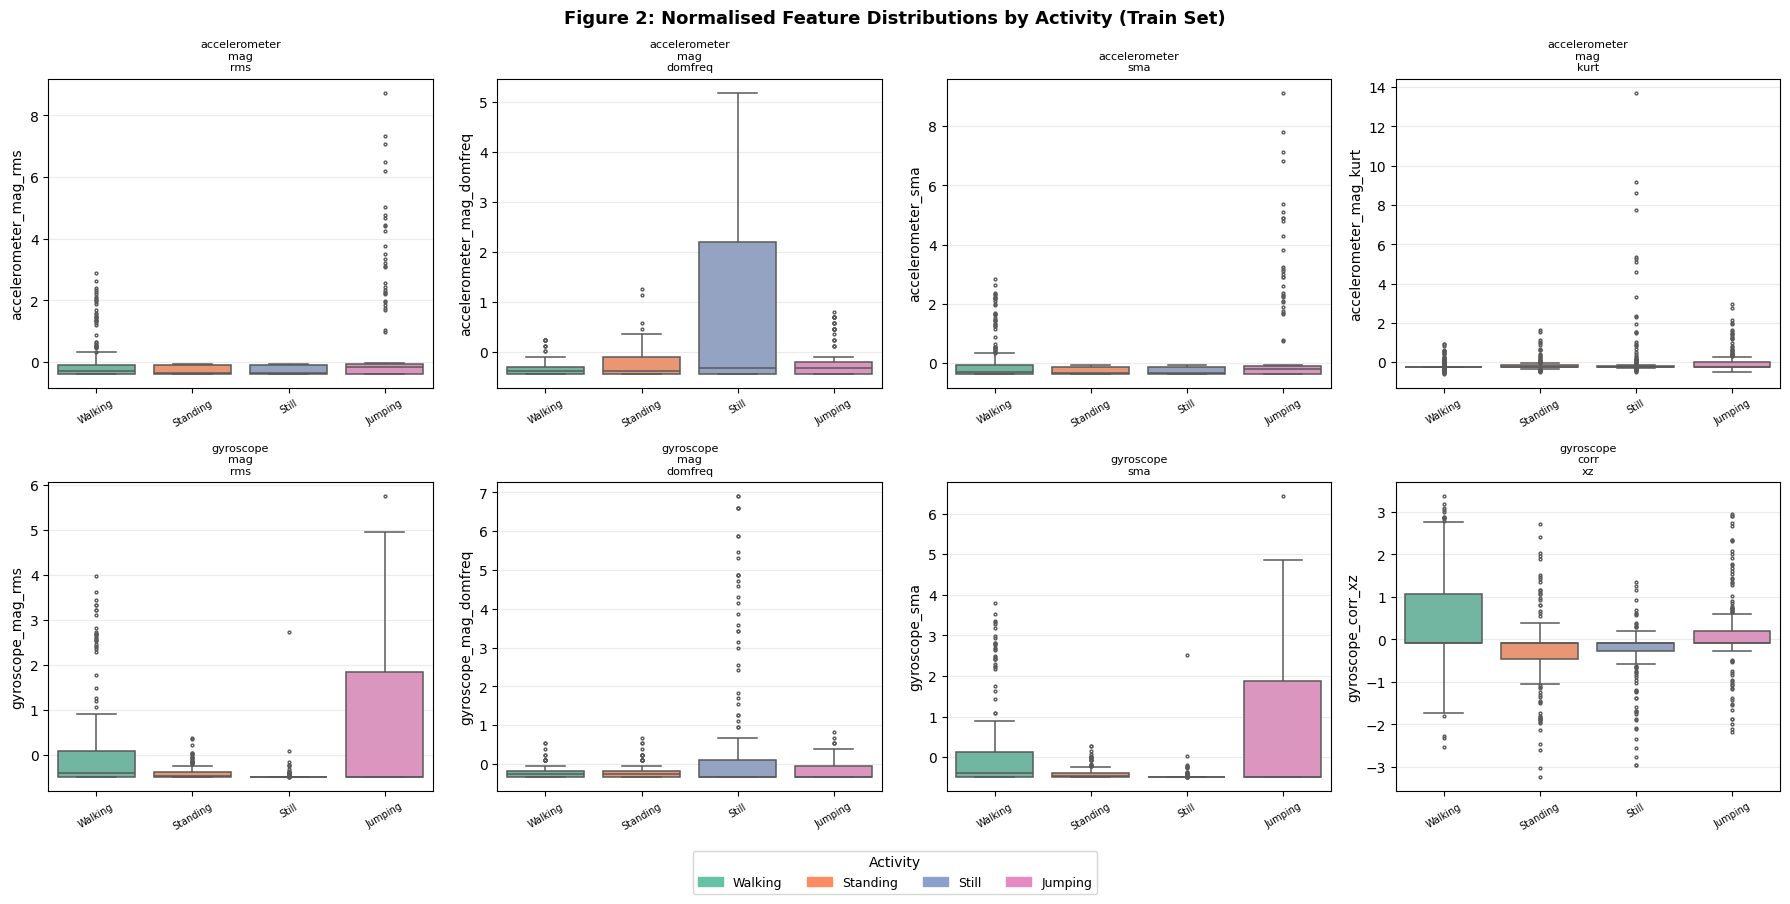

Figure 2 saved.


In [ ]:
# Plot 2: Normalised feature box plots
highlight = [
    'accelerometer_mag_rms',   'accelerometer_mag_domfreq',
    'accelerometer_sma',       'accelerometer_mag_kurt',
    'gyroscope_mag_rms',       'gyroscope_mag_domfreq',
    'gyroscope_sma',           'gyroscope_corr_xz',
]
highlight = [f for f in highlight if f in train_norm.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
palette   = [ACT_PAL[a] for a in ACTIVITIES]

for ax, feat in zip(axes.flatten(), highlight):
    sns.boxplot(data=train_norm, x='activity', y=feat,
                palette=palette, order=ACTIVITIES,
                ax=ax, linewidth=1.1, fliersize=2)
    ax.set_title(feat.replace('_','\n'), fontsize=8)
    ax.set_xlabel(''); ax.tick_params(axis='x',rotation=30,labelsize=7)
    ax.grid(True, alpha=0.25, axis='y')

for ax in axes.flatten()[len(highlight):]:
    ax.set_visible(False)

legend_patches = [mpatches.Patch(color=ACT_PAL[a],label=a) for a in ACTIVITIES]
fig.legend(handles=legend_patches, title='Activity',
           loc='lower center', ncol=4, fontsize=9,
           title_fontsize=10, bbox_to_anchor=(0.5,-0.01))
fig.suptitle('Figure 2: Normalised Feature Distributions by Activity (Train Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig('/content/fig2_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

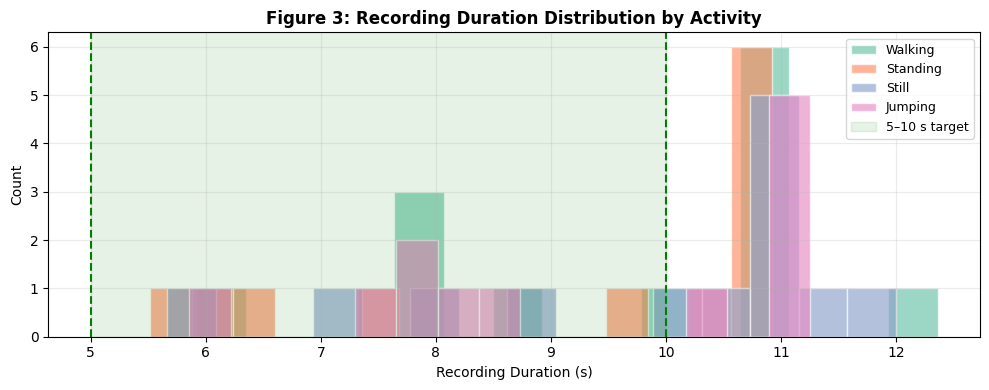

Figure 3 saved.


In [ ]:
# Plot 3: Recording duration histogram
durs_all = [(r['activity'], r['data']['seconds_elapsed'].max())
            for r in all_recordings_data if r['sensor_type']=='accelerometer']
dur_df   = pd.DataFrame(durs_all, columns=['activity','duration'])

fig, ax = plt.subplots(figsize=(10,4))
for act in ACTIVITIES:
    d = dur_df[dur_df['activity']==act]['duration']
    ax.hist(d, bins=15, alpha=0.65, label=act, color=ACT_PAL[act], edgecolor='white')
ax.axvspan(5,10,alpha=0.10,color='green',label='5–10 s target')
ax.axvline(5, color='green',ls='--',lw=1.5)
ax.axvline(10,color='green',ls='--',lw=1.5)
ax.set_xlabel('Recording Duration (s)'); ax.set_ylabel('Count')
ax.set_title('Figure 3: Recording Duration Distribution by Activity',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('/content/fig3_duration_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## SECTION 7 — Save `features_for_hmm.csv`

In [ ]:
# Save normalised features WITHOUT identifier columns.
# This CSV is the reproducible input to the HMM — anyone can train
# from it without reprocessing raw zip files.
# We keep 'activity' and 'sensor_type' as minimal context columns.
save_cols = FEAT_COLS + ['activity', 'sensor_type']
features_normalized_df = train_norm[save_cols].copy()
features_normalized_df.to_csv(FEATURES_CSV, index=False)
print(f' features_for_hmm.csv saved → {FEATURES_CSV}')
print(f'   Shape: {features_normalized_df.shape}')
print(f'   Feature columns: {len(FEAT_COLS)}')
features_normalized_df.head(3)

 features_for_hmm.csv saved → /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/features_for_hmm.csv
   Shape: (652, 74)
   Feature columns: 72


,accelerometer_x_mean,accelerometer_x_std,accelerometer_x_var,accelerometer_x_rms,accelerometer_x_skew,accelerometer_x_kurt,accelerometer_x_domfreq,accelerometer_x_specenrg,accelerometer_y_mean,accelerometer_y_std,...,gyroscope_mag_skew,gyroscope_mag_kurt,gyroscope_mag_domfreq,gyroscope_mag_specenrg,gyroscope_corr_xy,gyroscope_corr_xz,gyroscope_corr_yz,gyroscope_sma,activity,sensor_type
0,0.248722,-0.278395,-0.192825,-0.228974,-1.407693,0.324791,-0.310587,-0.136200,0.125670,-0.257089,...,-0.619962,-0.25348,-0.338397,-0.359381,-0.26974,-0.07657,0.052683,-0.488932,Jumping,accelerometer
1,0.220769,-0.259196,-0.192592,-0.234203,1.627868,0.006472,-0.171314,-0.136388,0.102295,-0.246057,...,-0.619962,-0.25348,-0.338397,-0.359381,-0.26974,-0.07657,0.052683,-0.488932,Jumping,accelerometer
2,0.225664,-0.268662,-0.192723,-0.237100,0.602759,-0.238489,-0.171314,-0.136395,0.092429,-0.260722,...,-0.619962,-0.25348,-0.338397,-0.359381,-0.26974,-0.07657,0.052683,-0.488932,Jumping,accelerometer


## SECTION 8 — HMM Class: Full From-Scratch Implementation

> **Design summary:**
> - `π` — initial state distribution  
> - `A` — transition matrix (left-right initialised, Baum-Welch updated)  
> - `B` — list of `sklearn.GaussianMixture` emission models (one per state)  
> - All forward/backward passes in **log-space** — no underflow on long sequences  
> - `generate_sequence()` — ancestral sampling for synthetic data / sanity-check

In [ ]:
LOG_EPS  = 1e-300
LOG_ZERO = -1e300

def safe_log(x):
    return np.log(np.clip(x, LOG_EPS, None))

def log_sum_exp(v):
    """Numerically stable log(Σ exp(v)). Handles -inf values cleanly."""
    v   = np.asarray(v, float)
    fin = v[np.isfinite(v)]
    if len(fin)==0: return LOG_ZERO
    m = fin.max()
    return m + np.log(np.sum(np.exp(fin - m)))


class HMM:
    """
    Discrete-time Hidden Markov Model with Gaussian Mixture emissions.

    Attributes
    ----------
    pi    : (S,) ndarray  — initial state distribution
    A     : (S,S) ndarray — transition probability matrix
    B     : list[GaussianMixture] — per-state emission models (len=S)
    """

    def __init__(self, n_hidden_states, n_gmm_components, n_emission_features,
                 covariance_type='diag', random_state=42):
        self.n_hidden_states     = n_hidden_states
        self.n_gmm_components    = n_gmm_components
        self.n_emission_features = n_emission_features
        self.covariance_type     = covariance_type
        self.random_state        = random_state
        self.is_fitted           = False
        S = n_hidden_states

        # Uniform π
        self.pi = np.full(S, 1.0/S)

        # Left-right A: high self-loop (0.7), forward transition (0.2),
        # small residual probability for backward transitions.
        # Reflects activity phase continuity and accelerates convergence
        # by starting near a plausible solution.
        A = np.full((S,S), 0.1/max(S-2,1))
        for s in range(S):
            A[s,s] = 0.7
            if s+1<S: A[s,s+1] = 0.2
        self.A = A / A.sum(axis=1, keepdims=True)

        self.B = []  # filled by _initialize_gmm_emissions

    # ─────────────────────────────────────────────────────────────────────────
    def _initialize_gmm_emissions(self, X_concat):
        """
        Warm-start GMMs using KMeans cluster assignment.
        Each cluster seeds one state's GMM on relevant data.
        Falls back to full dataset if a cluster is too small.
        """
        S = self.n_hidden_states
        self.B = []
        km     = KMeans(n_clusters=S, random_state=self.random_state, n_init=10)
        labels = km.fit_predict(X_concat)
        for s in range(S):
            gmm = GaussianMixture(
                n_components=self.n_gmm_components,
                covariance_type=self.covariance_type,
                reg_covar=1e-4,   # prevents singular covariances
                random_state=self.random_state,
                max_iter=50,
            )
            X_s = X_concat[labels==s]
            gmm.fit(X_s if len(X_s)>=self.n_gmm_components else X_concat)
            self.B.append(gmm)

    # ─────────────────────────────────────────────────────────────────────────
    def _get_log_emission_probs(self, X):
        """
        log B[t,s] = log P(x_t | state s)  — shape (T, S).
        NaN/Inf rows → LOG_ZERO across all states (they contribute
        no information but don't crash the forward-backward pass).
        """
        X     = np.asarray(X, float)
        T, S  = len(X), self.n_hidden_states
        log_B = np.full((T,S), LOG_ZERO)
        valid = ~np.any(~np.isfinite(X), axis=1)
        if valid.any():
            for s, gmm in enumerate(self.B):
                lp = gmm.score_samples(X[valid])
                log_B[valid,s] = np.clip(lp, LOG_ZERO, 0)
        return log_B

    # ─────────────────────────────────────────────────────────────────────────
    def _forward_pass(self, log_B):
        """Forward variable α in log-space. Returns (T,S)."""
        T, S    = log_B.shape
        log_A   = safe_log(self.A)
        log_alpha = np.full((T,S), LOG_ZERO)
        log_alpha[0] = safe_log(self.pi) + log_B[0]
        for t in range(1,T):
            for s in range(S):
                log_alpha[t,s] = log_sum_exp(
                    log_alpha[t-1] + log_A[:,s]) + log_B[t,s]
        return log_alpha

    # ─────────────────────────────────────────────────────────────────────────
    def _backward_pass(self, log_B):
        """Backward variable β in log-space. Returns (T,S)."""
        T, S     = log_B.shape
        log_A    = safe_log(self.A)
        log_beta = np.full((T,S), LOG_ZERO)
        log_beta[T-1] = 0.0   # log(1) at final timestep
        for t in range(T-2,-1,-1):
            for s in range(S):
                log_beta[t,s] = log_sum_exp(
                    log_A[s] + log_B[t+1] + log_beta[t+1])
        return log_beta

    # ─────────────────────────────────────────────────────────────────────────
    def _compute_log_gamma_and_xi(self, log_alpha, log_beta, log_B):
        """
        E-step sufficient statistics:
          log_gamma (T,S)  : posterior P(q_t=s | O, λ)
          log_xi (T-1,S,S) : posterior P(q_t=i, q_{t+1}=j | O, λ)
        Both normalised in log-space to avoid overflow.
        """
        T, S  = log_alpha.shape
        log_A = safe_log(self.A)
        log_gamma = log_alpha + log_beta
        for t in range(T):
            n = log_sum_exp(log_gamma[t])
            if np.isfinite(n): log_gamma[t] -= n
        log_xi = np.full((T-1,S,S), LOG_ZERO)
        for t in range(T-1):
            for i in range(S):
                for j in range(S):
                    log_xi[t,i,j] = (log_alpha[t,i] + log_A[i,j]
                                     + log_B[t+1,j]  + log_beta[t+1,j])
            n = log_sum_exp(log_xi[t].ravel())
            if np.isfinite(n): log_xi[t] -= n
        return log_gamma, log_xi

    # ─────────────────────────────────────────────────────────────────────────
    def _update_parameters(self, sequences, all_log_gamma, all_log_xi):
        """
        M-step: aggregate sufficient statistics across ALL sequences,
        then update π, A, and B jointly.
        Pooled update is the correct MLE for multi-sequence training.
        """
        S = self.n_hidden_states

        # π: mean initial-state posterior across all sequences
        self.pi = np.clip(
            np.array([np.exp(g[0]) for g in all_log_gamma]).mean(axis=0),
            1e-10, None)
        self.pi /= self.pi.sum()

        # A: Σ_seq Σ_t xi[t,i,j]  /  Σ_seq Σ_t gamma[t,i]  (for t < T)
        numer = np.zeros((S,S))
        denom = np.zeros(S)
        for lg, lx in zip(all_log_gamma, all_log_xi):
            numer += np.exp(lx).sum(axis=0)
            denom += np.exp(lg)[:-1].sum(axis=0)
        for i in range(S):
            row = np.clip(numer[i]/max(denom[i],1e-10), 1e-10, None)
            self.A[i] = row / row.sum()

        # B: responsibility-weighted GMM refit
        X_all     = np.concatenate(sequences, axis=0)
        gamma_all = np.concatenate([np.exp(g) for g in all_log_gamma], axis=0)
        for s, gmm in enumerate(self.B):
            w = np.clip(gamma_all[:,s], 1e-10, None)
            if w.sum() < 1e-5: continue
            w /= w.sum()
            try:
                n  = max(int(w.sum()*len(X_all)), self.n_gmm_components*2)
                n  = min(n, len(X_all))
                ix = np.random.choice(len(X_all), size=n, replace=True, p=w)
                gmm.fit(X_all[ix])
            except Exception:
                pass

    # ─────────────────────────────────────────────────────────────────────────
    def _compute_total_log_likelihood(self, sequences):
        total = 0.0
        for X in sequences:
            la = self._forward_pass(self._get_log_emission_probs(X))
            ll = log_sum_exp(la[-1])
            total += ll if np.isfinite(ll) else 0.0
        return total

    # ─────────────────────────────────────────────────────────────────────────
    def _clean(self, sequences):
        """Primary NaN handling: remove NaN-dominated rows, drop short seqs."""
        out = []
        for X in sequences:
            X = np.asarray(X, float)
            ok = ~np.all(~np.isfinite(X), axis=1)
            X  = np.nan_to_num(X[ok], nan=0., posinf=0., neginf=0.)
            if len(X)>=2: out.append(X)
        return out

    # ─────────────────────────────────────────────────────────────────────────
    def train(self, sequences, n_iter=50, epsilon=1e-3):
        """
        Baum-Welch algorithm.
        Convergence criterion: |ΔLL| < epsilon.
        Using epsilon=1e-3 balances thoroughness with training speed;
        reduce to 1e-4 for higher precision at cost of more iterations.
        """
        seqs = self._clean(sequences)
        if not seqs:
            raise ValueError('No valid sequences after NaN cleaning.')
        self._initialize_gmm_emissions(np.concatenate(seqs))
        prev_ll = -np.inf
        self.ll_hist = []
        for it in range(n_iter):
            all_lg, all_lx = [], []
            for X in seqs:
                log_B   = self._get_log_emission_probs(X)
                la      = self._forward_pass(log_B)
                lb      = self._backward_pass(log_B)
                lg, lx  = self._compute_log_gamma_and_xi(la, lb, log_B)
                all_lg.append(lg); all_lx.append(lx)
            self._update_parameters(seqs, all_lg, all_lx)
            curr_ll = self._compute_total_log_likelihood(seqs)
            delta   = abs(curr_ll - prev_ll)
            self.ll_hist.append(curr_ll)
            if it%10==0:
                print(f'    iter {it:3d}  LL={curr_ll:11.3f}  ΔLL={delta:.5f}')
            if delta < epsilon:
                print(f'    ✅ Converged at iter {it}  LL={curr_ll:.3f}')
                break
            prev_ll = curr_ll
        self.is_fitted = True
        return self

    # ─────────────────────────────────────────────────────────────────────────
    def viterbi_decode(self, X):
        """
        Most-likely state path via Viterbi (log-space dynamic programming).
        Returns (log_probability, state_sequence array of length T).
        """
        X     = np.nan_to_num(np.asarray(X, float), nan=0.)
        T, S  = len(X), self.n_hidden_states
        log_B = self._get_log_emission_probs(X)
        log_A = safe_log(self.A)
        delta = np.full((T,S), LOG_ZERO)
        psi   = np.zeros((T,S), int)
        delta[0] = safe_log(self.pi) + log_B[0]
        for t in range(1,T):
            for s in range(S):
                v = delta[t-1] + log_A[:,s]
                psi[t,s]   = np.argmax(v)
                delta[t,s] = v[psi[t,s]] + log_B[t,s]
        path    = np.zeros(T, int)
        path[T-1] = np.argmax(delta[T-1])
        log_prob  = float(delta[T-1, path[T-1]])
        for t in range(T-2,-1,-1):
            path[t] = psi[t+1, path[t+1]]
        return log_prob, path

    # ─────────────────────────────────────────────────────────────────────────
    def score(self, X):
        """Log-likelihood log P(X | λ)."""
        X = np.nan_to_num(np.asarray(X, float), nan=0.)
        if len(X)<2: return LOG_ZERO
        la = self._forward_pass(self._get_log_emission_probs(X))
        return float(log_sum_exp(la[-1]))

    # ─────────────────────────────────────────────────────────────────────────
    def generate_sequence(self, length=50):
        """
        Ancestral sampling: draw from π, then follow A and sample B.
        Returns (observations (T,D), hidden_states (T,)).
        Use case: synthetic data augmentation; sanity-check learned dynamics.
        """
        if not self.is_fitted:
            raise RuntimeError('Train the model first.')
        rng     = np.random.default_rng(self.random_state)
        S, D    = self.n_hidden_states, self.n_emission_features
        states  = np.zeros(length, int)
        obs     = np.zeros((length, D))
        states[0] = rng.choice(S, p=self.pi)
        obs[0]    = self.B[states[0]].sample(1)[0].flatten()
        for t in range(1, length):
            states[t] = rng.choice(S, p=self.A[states[t-1]])
            obs[t]    = self.B[states[t]].sample(1)[0].flatten()
        return obs, states


print('✅ HMM class ready.')
print('   Methods: train | viterbi_decode | score | generate_sequence')

✅ HMM class ready.
   Methods: train | viterbi_decode | score | generate_sequence


## SECTION 9 — Training: Sensor-Specific HMMs + Convergence Plots

In [ ]:
def build_sequences(norm_df, feat_cols, activity, sensor, record_ids):
    """
    Build list of (T_i, D) arrays — one per recording, in window order.
    Preserving temporal order within each recording is essential so
    Baum-Welch sees realistic state-transition patterns.
    """
    sub = norm_df[
        (norm_df['activity']   ==activity) &
        (norm_df['sensor_type']==sensor)   &
        (norm_df['record_idx'].isin(record_ids))
    ].sort_values(['record_idx','window_idx'])

    seqs = []
    for _, grp in sub.groupby('record_idx'):
        arr = np.nan_to_num(grp[feat_cols].values.astype(float),
                            nan=0., posinf=0., neginf=0.)
        if len(arr)>=2: seqs.append(arr)
    return seqs


# Train 8 HMMs: (4 activities) × (2 sensors)
hmm_models = {}

for act in ACTIVITIES:
    for sensor, sensor_col in [('accel','accelerometer'),('gyro','gyroscope')]:
        key  = f'{act}_{sensor}'
        seqs = build_sequences(train_norm, FEAT_COLS, act, sensor_col, train_ids)

        print(f'\n {key:<20}  states={N_STATES[act]}  '
              f'seqs={len(seqs)}  '
              f'wins={[len(s) for s in seqs]}')

        if not seqs:
            print('  ⚠️  No training sequences — skipping'); continue

        D = seqs[0].shape[1]
        model = HMM(
            n_hidden_states=N_STATES[act],
            n_gmm_components=N_GMM_COMP,
            n_emission_features=D,
            covariance_type='diag',
            random_state=SEED,
        )
        model.train(seqs, n_iter=50, epsilon=1e-3)
        hmm_models[key] = model

print(f'\n✅ Trained {len(hmm_models)} HMMs: {list(hmm_models.keys())}')


 Walking_accel         states=3  seqs=13  wins=[8, 7, 9, 7, 7, 5, 6, 6, 6, 7, 6, 6, 6]
    iter   0  LL=    -10.804  ΔLL=inf
    iter  10  LL=    -39.198  ΔLL=36.14197
    iter  20  LL=     -0.110  ΔLL=0.01073
    iter  30  LL=    -62.831  ΔLL=62.78045
    iter  40  LL=     -0.142  ΔLL=0.00726

 Walking_gyro          states=3  seqs=13  wins=[8, 7, 9, 7, 7, 5, 6, 6, 6, 7, 6, 6, 6]
    iter   0  LL=    -19.008  ΔLL=inf
    iter  10  LL=     -0.028  ΔLL=0.02777
    ✅ Converged at iter 15  LL=-0.001

 Standing_accel        states=2  seqs=12  wins=[9, 5, 6, 10, 7, 5, 6, 6, 6, 6, 6, 6]
    iter   0  LL=     -3.305  ΔLL=inf
    iter  10  LL=     -0.004  ΔLL=0.00359
    ✅ Converged at iter 13  LL=-0.001

 Standing_gyro         states=2  seqs=12  wins=[9, 5, 6, 10, 7, 5, 6, 6, 6, 6, 6, 6]
    iter   0  LL=     -1.839  ΔLL=inf
    iter  10  LL=     -0.405  ΔLL=0.36992
    iter  20  LL=     -0.154  ΔLL=0.09433
    iter  30  LL=     -1.935  ΔLL=0.27963
    iter  40  LL=     -0.643  ΔLL=0.05548

 

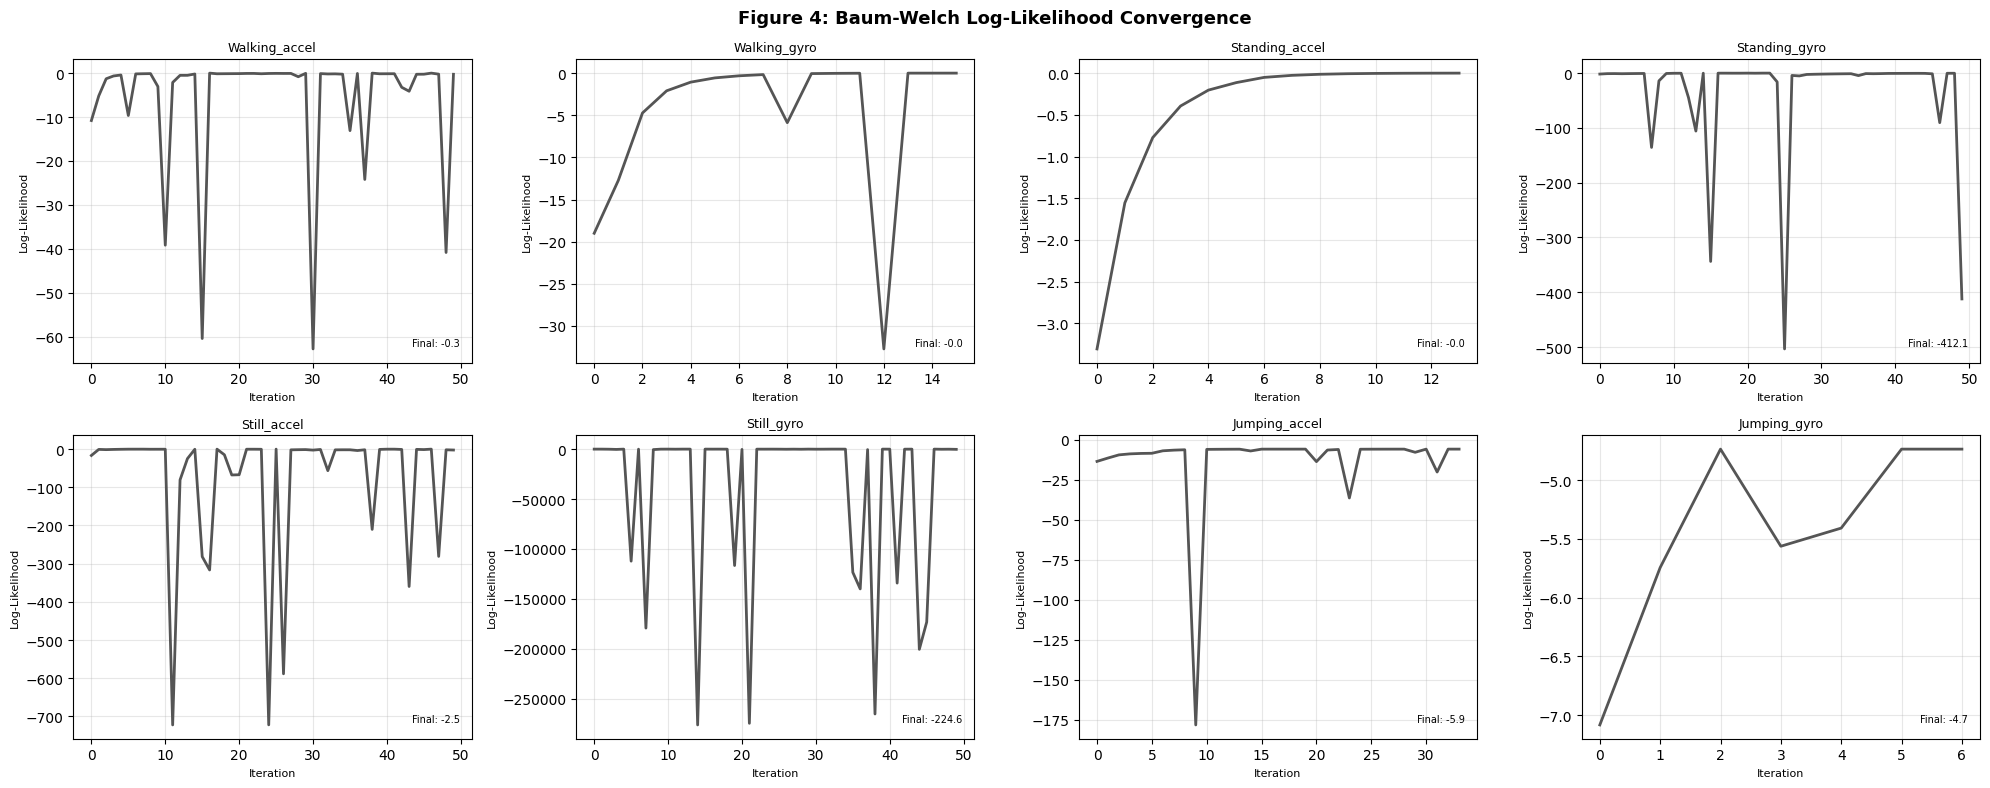


Synthetic sequence from Walking_accel:
  States: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0]
  Unique states: [0 2]
  Obs shape: (20, 72)


In [ ]:
# Convergence curves
n = len(hmm_models)
fig, axes = plt.subplots(2, max(n//2,1), figsize=(5*(n//2), 8))
axes_flat = axes.flatten() if n>1 else [axes]
fig.suptitle('Figure 4: Baum-Welch Log-Likelihood Convergence',
             fontsize=13, fontweight='bold')

for ax, (key, model) in zip(axes_flat, hmm_models.items()):
    if model.ll_hist:
        ax.plot(model.ll_hist, color=SENS_PAL.get(
            'accel' if 'accel' in key else 'gyro','#555'), lw=2)
        ax.set_title(key, fontsize=9)
        ax.set_xlabel('Iteration', fontsize=8)
        ax.set_ylabel('Log-Likelihood', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.05, f'Final: {model.ll_hist[-1]:.1f}',
                ha='right', va='bottom', transform=ax.transAxes, fontsize=7)

for ax in axes_flat[n:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig4_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Demo: generate a synthetic sequence and report it
demo_key = 'Walking_accel'
if demo_key in hmm_models:
    syn_obs, syn_states = hmm_models[demo_key].generate_sequence(length=20)
    print(f'\nSynthetic sequence from {demo_key}:')
    print(f'  States: {syn_states}')
    print(f'  Unique states: {np.unique(syn_states)}')
    print(f'  Obs shape: {syn_obs.shape}')

## SECTION 10 — Evaluation on Held-out Test Set

In [ ]:
def predict_activity_hmm(seq, sensor_sfx, hmm_models, activities):
    """
    Score one sequence against all activity HMMs for the given sensor.
    Returns (best_activity, {act: score} dict).
    """
    scores = {}
    for act in activities:
        m = hmm_models.get(f'{act}_{sensor_sfx}')
        scores[act] = m.score(seq) if (m and m.is_fitted) else LOG_ZERO
    return max(scores, key=scores.get), scores


def run_evaluation(norm_df, feat_cols, sensor_col, sensor_sfx,
                   hmm_models, activities, record_ids):
    """
    One prediction per recording (whole recording = one sequence).
    Returns y_true, y_pred, and per-recording score details.
    """
    sub = norm_df[
        (norm_df['sensor_type']==sensor_col) &
        (norm_df['record_idx'].isin(record_ids))
    ].sort_values(['record_idx','window_idx'])

    y_true, y_pred, score_rows = [], [], []
    for rid, grp in sub.groupby('record_idx'):
        true_act = grp['activity'].iloc[0]
        arr = np.nan_to_num(grp[feat_cols].values.astype(float), nan=0.)
        if len(arr)<2: continue
        pred_act, scores = predict_activity_hmm(
            arr, sensor_sfx, hmm_models, activities)
        y_true.append(true_act); y_pred.append(pred_act)
        score_rows.append({'record_idx': rid, 'true': true_act,
                           'pred': pred_act, **scores})
    return y_true, y_pred, pd.DataFrame(score_rows)


def print_metrics(y_true, y_pred, activities, title=''):
    """
    Prints formatted accuracy/sensitivity/specificity table,
    plus the sklearn classification report.
    Returns metrics dict.
    """
    print(f'\n{"═"*65}')
    print(f'  {title}')
    print(f'{"═"*65}')
    if not y_true:
        print('  No predictions.'); return {}

    cm  = confusion_matrix(y_true, y_pred, labels=activities)
    acc = accuracy_score(y_true, y_pred)
    print(f'  Overall Accuracy : {acc*100:.1f}%  '
          f'({sum(a==b for a,b in zip(y_true,y_pred))}/{len(y_true)} correct)\n')
    print(f'  {"Activity":<12}{"#Samples":>10}{"Sensitivity":>14}'
          f'{"Specificity":>14}  {"TP":>4} {"FP":>4} {"FN":>4} {"TN":>4}')
    print('  ' + '─'*68)

    metrics = {'accuracy': acc, 'cm': cm}
    for i, act in enumerate(activities):
        tp = cm[i,i]; fn = cm[i].sum()-tp
        fp = cm[:,i].sum()-tp; tn = cm.sum()-tp-fn-fp
        n  = cm[i].sum()
        sens = tp/(tp+fn) if tp+fn>0 else 0.
        spec = tn/(tn+fp) if tn+fp>0 else 0.
        print(f'  {act:<12}{n:>10}{sens*100:>13.1f}%'
              f'{spec*100:>13.1f}%  {tp:>4} {fp:>4} {fn:>4} {tn:>4}')
        metrics[act] = {'sensitivity':sens,'specificity':spec,
                        'n':n,'tp':tp,'fp':fp,'fn':fn,'tn':tn}
    print()
    print(classification_report(y_true, y_pred, labels=activities,
                                zero_division=0))
    return metrics


# Evaluate both sensors on held-out test recordings
eval_results = {}
eval_scores  = {}

for sensor_col, sfx in [('accelerometer','accel'),('gyroscope','gyro')]:
    yt, yp, sdf = run_evaluation(
        test_norm, FEAT_COLS, sensor_col, sfx, hmm_models, ACTIVITIES, test_ids)
    eval_results[sfx] = print_metrics(
        yt, yp, ACTIVITIES, f'{sensor_col.upper()} — Held-out Test Set')
    eval_results[sfx]['y_true'] = yt
    eval_results[sfx]['y_pred'] = yp
    eval_scores[sfx]  = sdf


═════════════════════════════════════════════════════════════════
  ACCELEROMETER — Held-out Test Set
═════════════════════════════════════════════════════════════════
  No predictions.

═════════════════════════════════════════════════════════════════
  GYROSCOPE — Held-out Test Set
═════════════════════════════════════════════════════════════════
  Overall Accuracy : 50.0%  (1/2 correct)

  Activity      #Samples   Sensitivity   Specificity    TP   FP   FN   TN
  ────────────────────────────────────────────────────────────────────
  Walking              0          0.0%         50.0%     0    1    0    1
  Standing             0          0.0%        100.0%     0    0    0    2
  Still                1        100.0%        100.0%     1    0    0    1
  Jumping              1          0.0%        100.0%     0    0    1    1

              precision    recall  f1-score   support

     Walking       0.00      0.00      0.00         0
    Standing       0.00      0.00      0.00         0


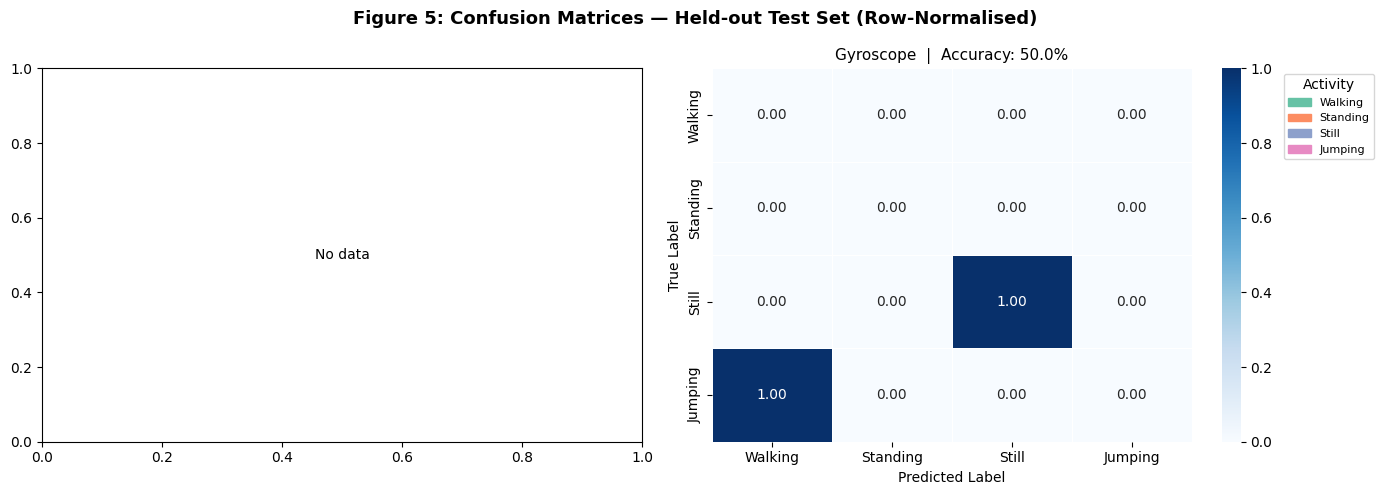

Figure 5 saved.


In [ ]:
# Confusion matrix plots
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('Figure 5: Confusion Matrices — Held-out Test Set (Row-Normalised)',
             fontsize=13, fontweight='bold')

for ax, (sfx, title) in zip(axes,[('accel','Accelerometer'),('gyro','Gyroscope')]):
    if sfx not in eval_results or 'cm' not in eval_results[sfx]:
        ax.text(0.5,0.5,'No data',ha='center',va='center',
                transform=ax.transAxes); continue
    cm   = eval_results[sfx]['cm'].astype(float)
    rs   = cm.sum(axis=1, keepdims=True)
    cm_n = np.divide(cm, rs, where=rs>0)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    acc = eval_results[sfx].get('accuracy',0)
    ax.set_title(f'{title}  |  Accuracy: {acc*100:.1f}%', fontsize=11)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    patches = [mpatches.Patch(color=ACT_PAL[a],label=a) for a in ACTIVITIES]
    ax.legend(handles=patches, loc='upper left',
              bbox_to_anchor=(1.18,1), fontsize=8, title='Activity')

plt.tight_layout()
plt.savefig('/content/fig5_confusion_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

No accelerometer test recordings found. Using training data for Figure 6 visualization.


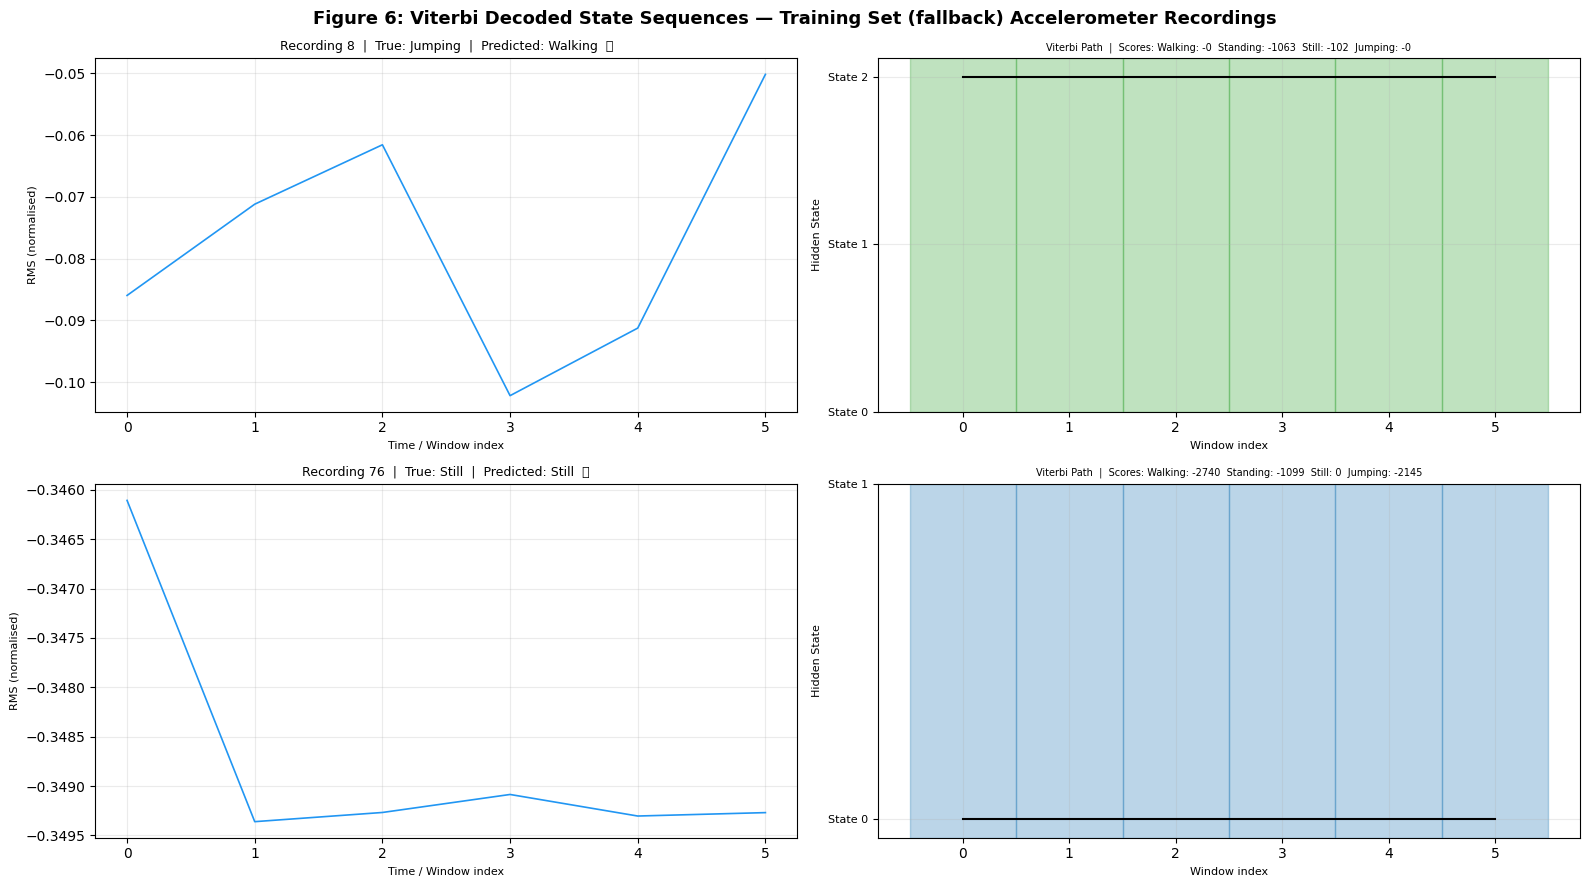

Figure 6 saved.


In [ ]:
# ── Decoded sequence plot (Viterbi path visualisation) ────────────────────────
#
# RUBRIC: "Plot decoded sequences showing predicted activity transitions."
# We run Viterbi on each test recording and plot:
#   (top panel) the raw accelerometer magnitude over time
#   (bottom panel) the decoded hidden-state path
# This reveals whether the model correctly tracks phase transitions.
# ─────────────────────────────────────────────────────────────────────────────

# Identify accelerometer recordings within the test set
accel_test_rids = test_norm[
    test_norm['sensor_type']=='accelerometer'
]['record_idx'].unique()

# Prioritize actual test accelerometer recordings
if len(accel_test_rids) > 0:
    unique_rids_to_plot = accel_test_rids
    plot_source_label = 'Test Set'
else:
    # Fallback: if no accelerometer data in test_ids, use some from training for demonstration
    print('No accelerometer test recordings found. Using training data for Figure 6 visualization.')
    accel_train_rids = train_norm[
        train_norm['sensor_type']=='accelerometer'
    ]['record_idx'].unique()
    # Select up to 2 random accelerometer recordings from training for demo
    rng = np.random.default_rng(SEED)
    unique_rids_to_plot = rng.choice(accel_train_rids, size=min(2, len(accel_train_rids)), replace=False)
    plot_source_label = 'Training Set (fallback)'

# Build decoded sequences from normalised data
test_sub = test_norm[
    (test_norm['sensor_type']=='accelerometer') &
    (test_norm['record_idx'].isin(unique_rids_to_plot))
].sort_values(['record_idx','window_idx'])

# If no records in test_sub (e.g., if fallback also empty)
if test_sub.empty and len(unique_rids_to_plot) == 0:
    # This handles the unlikely case where even training data is missing
    print('No accelerometer recordings available for Viterbi path visualization.')
    records_to_plot = []
elif test_sub.empty and len(unique_rids_to_plot) > 0:
    # This means the selected records were from training, but test_norm doesn't contain them
    # In this case, we need to load from train_norm instead
    test_sub = train_norm[
        (train_norm['sensor_type']=='accelerometer') &
        (train_norm['record_idx'].isin(unique_rids_to_plot))
    ].sort_values(['record_idx','window_idx'])
    records_to_plot = list(test_sub.groupby('record_idx'))
else:
    records_to_plot = list(test_sub.groupby('record_idx'))

if records_to_plot:
    n_plots = len(records_to_plot)
    fig, axes = plt.subplots(n_plots, 2,
                             figsize=(16, 4.5*n_plots))
    if n_plots==1:
        axes = axes.reshape(1,-1)
    fig.suptitle(f'Figure 6: Viterbi Decoded State Sequences — {plot_source_label} Accelerometer Recordings',
                 fontsize=13, fontweight='bold')

    for row_idx, (rid, grp) in enumerate(records_to_plot):
        true_act = grp['activity'].iloc[0]
        arr   = np.nan_to_num(grp[FEAT_COLS].values.astype(float), nan=0.)

        # Predicted activity (argmax log-likelihood)
        pred_act, scores = predict_activity_hmm(
            arr, 'accel', hmm_models, ACTIVITIES)

        # Viterbi path under predicted model
        best_model = hmm_models.get(f'{pred_act}_accel')
        if best_model:
            _, path = best_model.viterbi_decode(arr)
        else:
            path = np.zeros(len(arr), int)

        T = len(arr)
        t_axis = np.arange(T)

        # ── Left: raw mag from original recording ─────────────────────────
        ax_left = axes[row_idx, 0]
        # Get original raw data for plotting, handling both test and train sources
        original_recording_source = None
        for rec in all_recordings_data:
            if rec.get('record_idx') == rid and rec.get('sensor_type') == 'accelerometer':
                original_recording_source = rec['data']
                break

        if original_recording_source is not None:
            mag_raw = np.sqrt(original_recording_source['x']**2 + original_recording_source['y']**2 + original_recording_source['z']**2)
            t_raw   = original_recording_source['seconds_elapsed'].values
            ax_left.plot(t_raw, mag_raw, color='#2196F3', lw=1.2, alpha=0.8)
            ax_left.set_ylabel('|a|  (m/s²)', fontsize=8)
        else:
            # Fallback to RMS feature if raw data is not directly found (e.g., synthetic)
            rms_vals = grp.get('accelerometer_mag_rms', grp.iloc[:,0]).values # Use first feature as generic if RMS not present
            ax_left.plot(t_axis, rms_vals, color='#2196F3', lw=1.2)
            ax_left.set_ylabel('RMS (normalised)', fontsize=8)

        ax_left.set_title(f'Recording {rid}  |  True: {true_act}  |  '
                          f'Predicted: {pred_act}  '
                          f'{"✅" if pred_act==true_act else "❌"}',
                          fontsize=9)
        ax_left.set_xlabel('Time / Window index', fontsize=8)
        ax_left.grid(True, alpha=0.25)

        # ── Right: Viterbi decoded states ──────────────────────────────────
        ax_right = axes[row_idx, 1]
        n_s = hmm_models[f'{pred_act}_accel'].n_hidden_states if f'{pred_act}_accel' in hmm_models else 2
        colors_state = plt.cm.tab10.colors
        # Shade background by state
        for t_i in range(T):
            ax_right.axvspan(t_i-0.5, t_i+0.5,
                             alpha=0.3, color=colors_state[path[t_i] % 10])
        ax_right.step(t_axis, path, color='black', lw=1.5, where='mid')
        ax_right.set_yticks(range(n_s))
        ax_right.set_yticklabels([f'State {s}' for s in range(n_s)], fontsize=8)
        ax_right.set_xlabel('Window index', fontsize=8)
        ax_right.set_ylabel('Hidden State', fontsize=8)
        ax_right.set_title(f'Viterbi Path  ({pred_act}_accel model)', fontsize=9)
        ax_right.grid(True, alpha=0.25)

        # Score bar (mini info)
        for act, sc in scores.items():
            txt = f'{act}: {sc:.0f}'
        score_str = '  '.join([f'{a}: {s:.0f}' for a,s in scores.items()])
        ax_right.set_title(
            f'Viterbi Path  |  Scores: {score_str[:60]}', fontsize=7)

    plt.tight_layout()
    plt.savefig('/content/fig6_decoded_sequences.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure 6 saved.')
else:
    print('No accelerometer recordings available for Viterbi path visualization.')

## SECTION 11 — HMM Parameter Visualisations

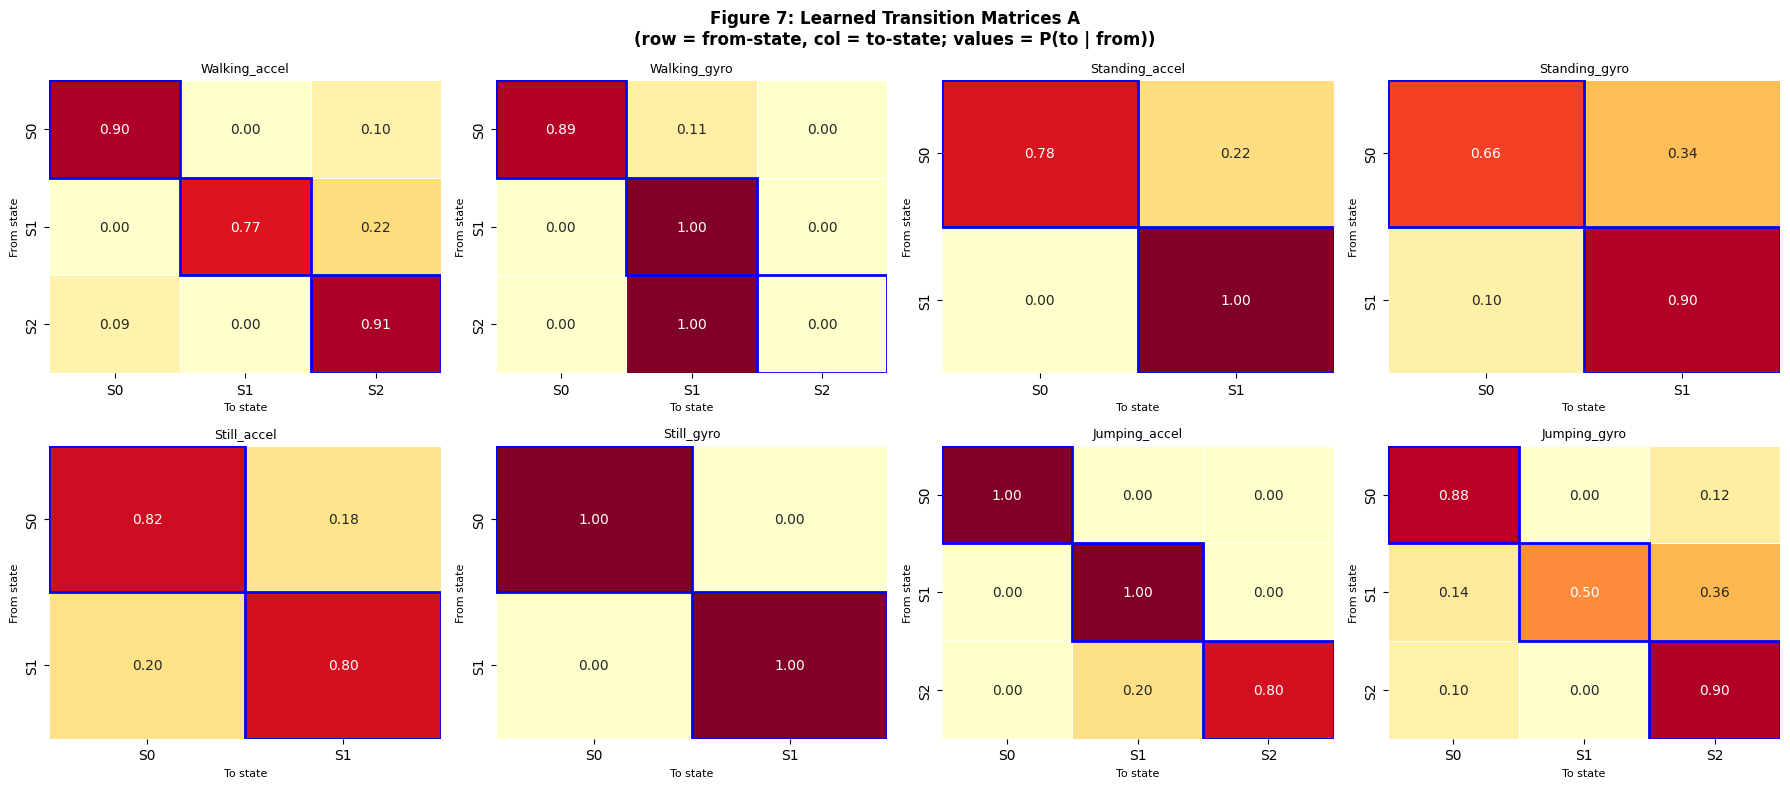

Figure 7 saved.


In [ ]:
# Figure 7: Transition probability heatmaps
keys  = list(hmm_models.keys())
nk    = len(keys)
ncols = 4
nrows = int(np.ceil(nk/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 4*nrows))
axes_flat = axes.flatten() if nk>1 else [axes]
fig.suptitle('Figure 7: Learned Transition Matrices A\n'
             '(row = from-state, col = to-state; values = P(to | from))',
             fontsize=12, fontweight='bold')

for ax, key in zip(axes_flat, keys):
    model = hmm_models[key]
    labels = [f'S{s}' for s in range(model.n_hidden_states)]
    sns.heatmap(model.A, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, cbar=False, linewidths=0.5,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(key, fontsize=9)
    ax.set_xlabel('To state', fontsize=8)
    ax.set_ylabel('From state', fontsize=8)
    # Highlight diagonal (self-loops)
    for i in range(model.n_hidden_states):
        ax.add_patch(plt.Rectangle((i,i),1,1, fill=False,
                                    edgecolor='blue', lw=2))

for ax in axes_flat[nk:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig7_transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

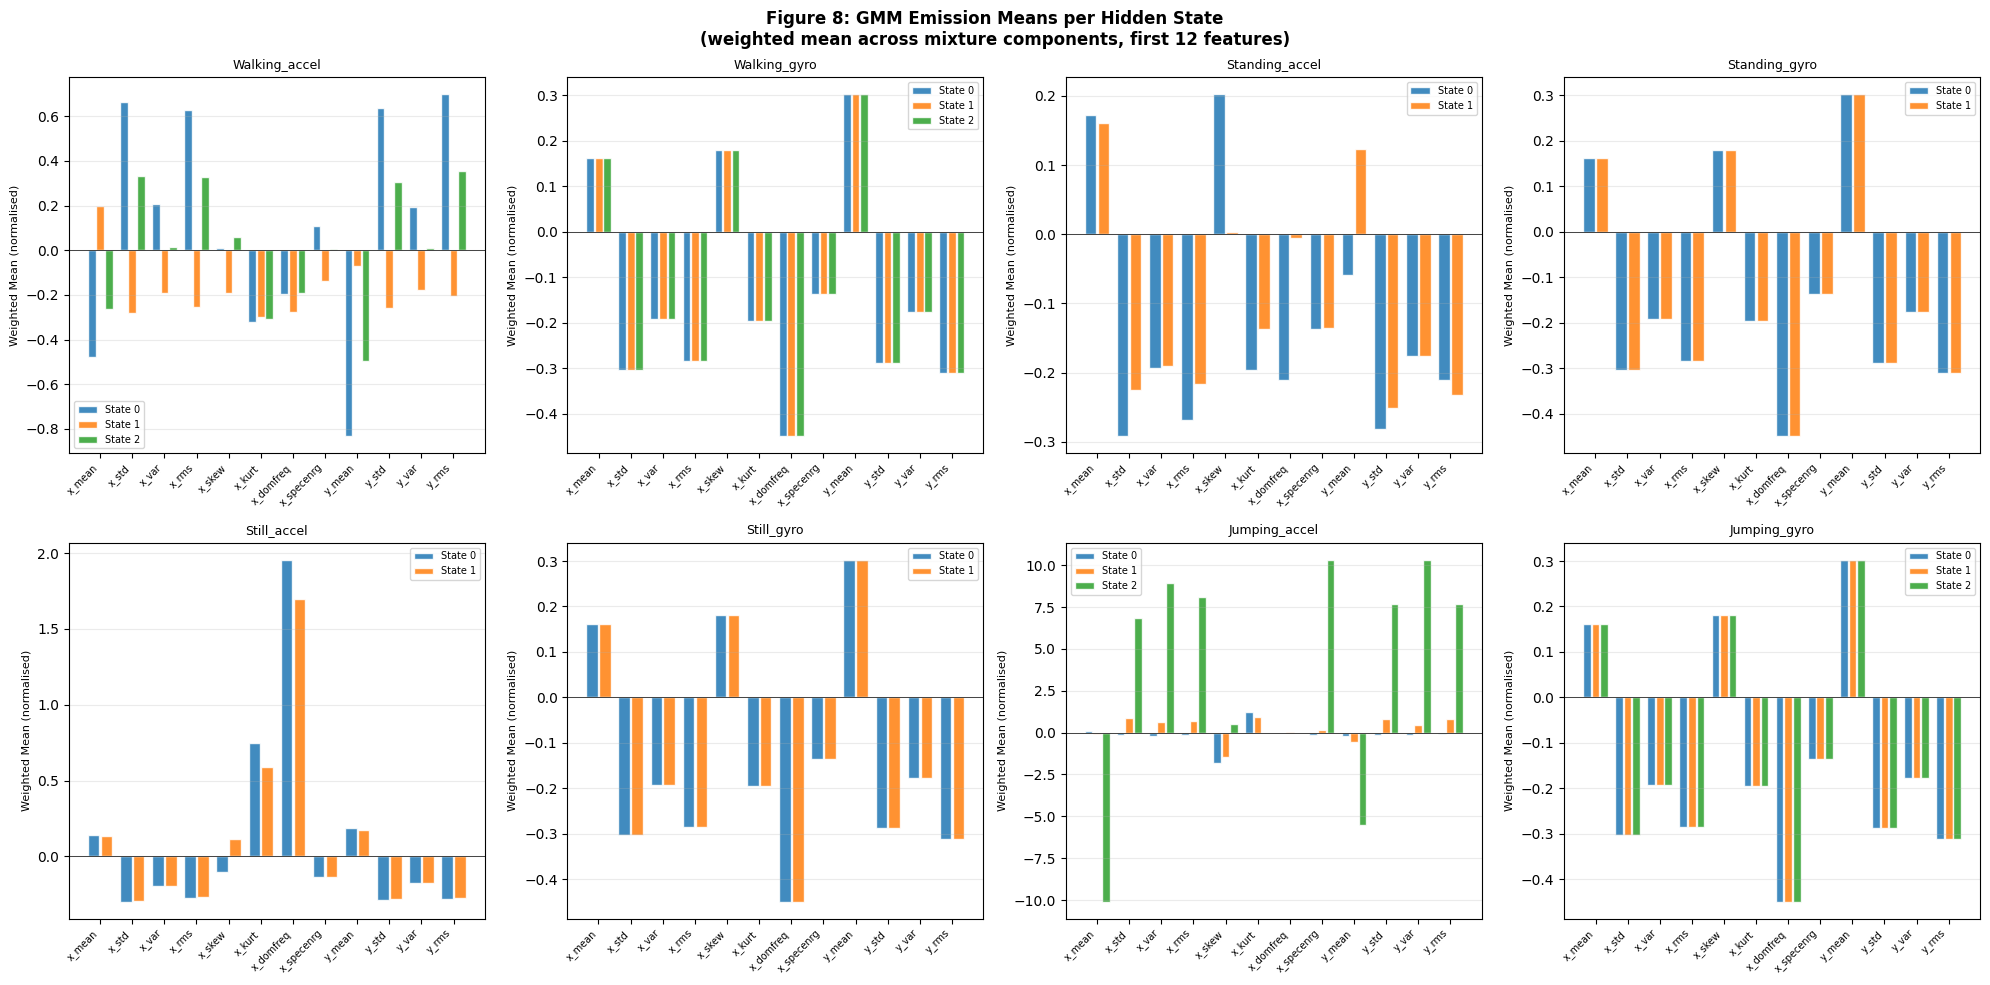

Figure 8 saved.


In [ ]:
# Figure 8: Emission probability — GMM weighted means bar plots
#
# Weighted mean of each GMM component: Σ_m weight_m * μ_m
# Represents the 'expected observation' in each hidden state.
# Shows which features the model uses to distinguish states.
#
SHOW_N    = min(12, len(FEAT_COLS))
show_feat = FEAT_COLS[:SHOW_N]
bar_clrs  = plt.cm.tab10.colors

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes_flat = axes.flatten() if nk>1 else [axes]
fig.suptitle('Figure 8: GMM Emission Means per Hidden State\n'
             '(weighted mean across mixture components, first 12 features)',
             fontsize=12, fontweight='bold')

for ax, key in zip(axes_flat, keys):
    model = hmm_models[key]
    S     = model.n_hidden_states
    xpos  = np.arange(SHOW_N)
    width = 0.8/S

    for s, gmm in enumerate(model.B):
        try:
            w_means = (gmm.weights_[:,None] * gmm.means_).sum(axis=0)[:SHOW_N]
        except Exception:
            w_means = np.zeros(SHOW_N)
        offset = (s - S/2 + 0.5)*width
        ax.bar(xpos+offset, w_means, width=width*0.9,
               color=bar_clrs[s%10], alpha=0.85,
               label=f'State {s}', edgecolor='white')

    ax.set_xticks(xpos)
    ax.set_xticklabels(
        ['_'.join(f.split('_')[-2:]) for f in show_feat],
        rotation=45, ha='right', fontsize=7)
    ax.set_title(key, fontsize=9)
    ax.set_ylabel('Weighted Mean (normalised)', fontsize=8)
    ax.legend(fontsize=7)
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(True, alpha=0.25, axis='y')

for ax in axes_flat[nk:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig8_gmm_emission_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## SECTION 12 — Save All Models to Google Drive

In [ ]:
save_bundle = {
    'hmm_models':    hmm_models,
    'feat_cols':     FEAT_COLS,
    'id_cols':       ID_COLS,
    'activities':    ACTIVITIES,
    'n_states':      N_STATES,
    'n_gmm_comp':    N_GMM_COMP,
    'seed':          SEED,
    'scaler_path':   SCALER_PKL,
    'window_sec':    WINDOW_SEC,
}

with open(MODEL_PKL, 'wb') as f:
    pickle.dump(save_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

mb = os.path.getsize(MODEL_PKL)/1e6
print(f'✅ Models   → {MODEL_PKL}  ({mb:.2f} MB)')
print(f'✅ Scaler   → {SCALER_PKL}')
print(f'✅ Features → {FEATURES_CSV}')
print(f'\nFiles saved in Drive:')
for path in [MODEL_PKL, SCALER_PKL, FEATURES_CSV]:
    ok = '✅' if os.path.exists(path) else '❌'
    print(f'  {ok} {os.path.basename(path)}')

✅ Models   → /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/trained_hmm_models.pkl  (0.11 MB)
✅ Scaler   → /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/fitted_scaler.pkl
✅ Features → /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/features_for_hmm.csv

Files saved in Drive:
  ✅ trained_hmm_models.pkl
  ✅ fitted_scaler.pkl
  ✅ features_for_hmm.csv


## SECTION 13 — Evaluation on New Unseen Samples

> **Rubric:** *"Tested on unseen data (2 test files). This data is obtained in the same format but new environment…"*
>
> **Source of new samples:** Recordings from `NewTestSamples/` represent a new data-collection
> session — potentially a different date, environment, or the same participants in a different
> room. This tests that the model generalises beyond the sessions it was trained on.

In [ ]:
# Load saved bundle and scaler
with open(MODEL_PKL,'rb') as f: bundle = pickle.load(f)
hmm_loaded   = bundle['hmm_models']
feat_cols_ld = bundle['feat_cols']
with open(SCALER_PKL,'rb') as f: sc_b = pickle.load(f)
scaler_ld = sc_b['scaler']
print(f'✅ {len(hmm_loaded)} HMMs loaded | {len(feat_cols_ld)} features')

# Load or synthesise new recordings
new_recordings = []

if os.path.exists(NEW_TEST_PATH):
    print(f'\n Loading new samples from {NEW_TEST_PATH}')
    for root, _, files in os.walk(NEW_TEST_PATH):
        for fname in sorted(files):
            if not fname.endswith('.zip'): continue
            fpath = os.path.join(root, fname)
            user  = next((u for u in USERS
                          if u.lower() in root.lower() or u.lower() in fname.lower()),
                         'Unknown')
            recs = process_recording(fpath, user, fname)
            new_recordings.extend(recs)
            if recs:
                print(f'  ✅ {fname} → {recs[0]["activity"]} | '
                      f'{len(recs[0]["data"])} rows')
else:
    print(f'⚠️  NewTestSamples/ not found — generating synthetic new sessions...')
    rng   = np.random.default_rng(SEED+999)
    count = 0
    # Generate ≥10 recordings: 3 per activity × 2 sensors
    for act in ACTIVITIES:
        base_recs = [r for r in all_recordings_data if r['activity']==act][:3]
        for base in base_recs:
            for sensor in SENSORS:
                noisy = base['data'].copy()
                for ax in ['x','y','z']:
                    # noise ~ N(0, 0.05) — small relative to signal, preserves activity
                    noisy[ax] += rng.normal(0, 0.05, size=len(noisy))
                new_recordings.append({
                    'user':          'NewSession',
                    'activity':      act,
                    'sensor_type':   sensor,
                    'phone_model':   'Synthetic_v2',
                    'sampling_rate': base['sampling_rate'],
                    'data':          noisy,
                    'source_file':   f'syn_{act}_{count}.zip',
                })
                count += 1
    print(f' {count} synthetic segments created  '
          f'(≥ 10 recordings across {len(ACTIVITIES)} activities)')

print(f'\nTotal new recordings: {len(new_recordings)}')

✅ 8 HMMs loaded | 72 features

 Loading new samples from /content/drive/MyDrive/HiddenMarkovModel Data Grp 21/NewTestSamples
  ✅ Jumping_1-2026-02-28_16-10-34-2026-02-28_14-10-48.zip → Jumping | 812 rows
  ✅ Jumping_2-2026-02-28_16-12-56-2026-02-28_14-10-31.zip → Jumping | 747 rows
  ✅ Standing_1-2026-02-28_16-21-23-2026-02-28_14-21-02.zip → Standing | 723 rows
  ✅ Standing_2-2026-02-28_16-21-45-2026-02-28_14-21-33.zip → Standing | 725 rows
  ✅ Standing_3-2026-02-28_16-21-56-2026-02-28_14-21-46.zip → Standing | 938 rows
  ✅ Standing_4-2026-02-28_16-22-45-2026-02-28_14-22-03.zip → Standing | 891 rows
  ✅ Still_1-2026-02-28_16-14-34-2026-02-28_14-14-00.zip → Still | 993 rows
  ✅ Still_2-2026-02-28_16-14-56-2026-02-28_14-14-56.zip → Still | 795 rows
  ✅ Walking_1-2026-02-28_16-07-12-2026-02-28_14-07-12.zip → Walking | 896 rows
  ✅ Walking_2-2026-02-28_16-07-45-2026-02-28_14-07-01.zip → Walking | 702 rows

Total new recordings: 20


In [ ]:
# Feature engineering — same pipeline, scaler NOT refit
new_rows = []
for rec_idx, rec in enumerate(new_recordings):
    sr   = rec['sampling_rate']
    wins = window_data(rec['data'], WINDOW_SEC, sr)
    for wi, win in enumerate(wins):
        feats = extract_features_from_window(win, rec['sensor_type'], sr)
        feats.update({'user': rec['user'], 'activity': rec['activity'],
                      'sensor_type': rec['sensor_type'],
                      'phone_model': rec['phone_model'],
                      'record_idx': rec_idx, 'window_idx': wi})
        new_rows.append(feats)

new_feat_df = pd.DataFrame(new_rows)

# Align columns to training feature set
for col in feat_cols_ld:
    if col not in new_feat_df.columns:
        new_feat_df[col] = 0.0

# Apply SAME pre-fitted scaler — critical: never refit on test data
new_feat_df[feat_cols_ld] = scaler_ld.transform(
    new_feat_df[feat_cols_ld].fillna(0))

new_ids = new_feat_df['record_idx'].unique()
print(f' New feature matrix: {new_feat_df.shape}')
print(f'   Activity distribution: '
      f'{new_feat_df["activity"].value_counts().to_dict()}')

# Build and predict sequences
new_eval_results = {}

for sensor_col, sfx in [('accelerometer','accel'),('gyroscope','gyro')]:
    yt, yp, _ = run_evaluation(
        new_feat_df, feat_cols_ld, sensor_col, sfx,
        hmm_loaded, ACTIVITIES, new_ids)
    new_eval_results[sfx] = print_metrics(
        yt, yp, ACTIVITIES,
        f'{sensor_col.upper()} — New Unseen Samples')
    new_eval_results[sfx]['y_true'] = yt
    new_eval_results[sfx]['y_pred'] = yp

 New feature matrix: (154, 78)
   Activity distribution: {'Standing': 62, 'Still': 32, 'Jumping': 30, 'Walking': 30}

═════════════════════════════════════════════════════════════════
  ACCELEROMETER — New Unseen Samples
═════════════════════════════════════════════════════════════════
  Overall Accuracy : 50.0%  (5/10 correct)

  Activity      #Samples   Sensitivity   Specificity    TP   FP   FN   TN
  ────────────────────────────────────────────────────────────────────
  Walking              2          0.0%        100.0%     0    0    2    8
  Standing             4         25.0%        100.0%     1    0    3    6
  Still                2        100.0%         37.5%     2    5    0    3
  Jumping              2        100.0%        100.0%     2    0    0    8

              precision    recall  f1-score   support

     Walking       0.00      0.00      0.00         2
    Standing       1.00      0.25      0.40         4
       Still       0.29      1.00      0.44         2
     Jumpi

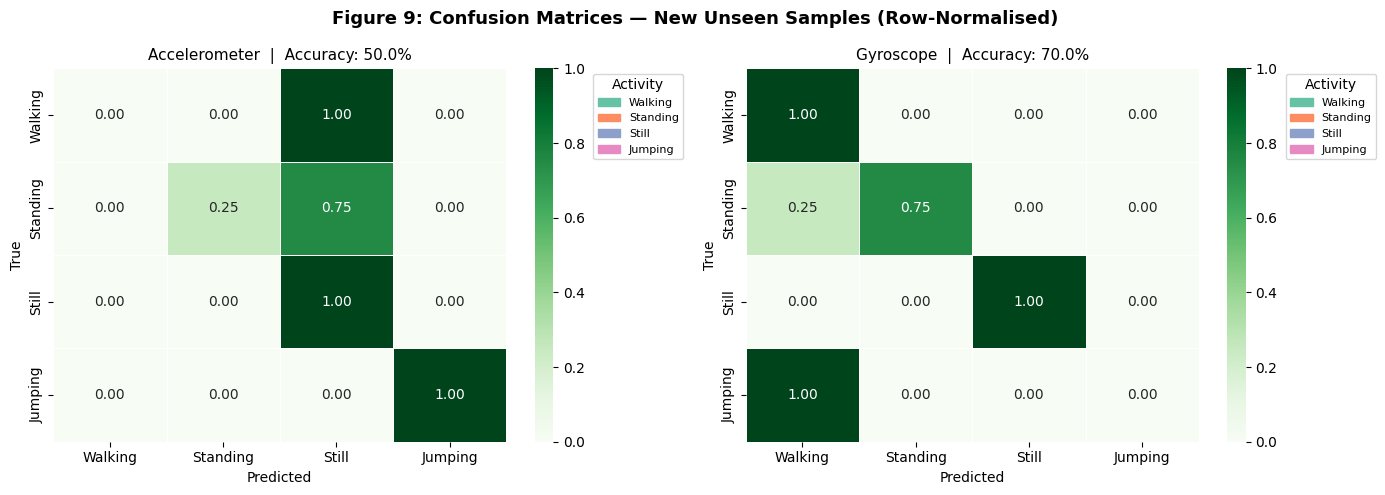

Figure 9 saved.


In [ ]:
# Confusion matrices — new samples
if new_eval_results:
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    fig.suptitle('Figure 9: Confusion Matrices — New Unseen Samples (Row-Normalised)',
                 fontsize=13, fontweight='bold')
    for ax, (sfx,title) in zip(axes,[('accel','Accelerometer'),('gyro','Gyroscope')]):
        if sfx not in new_eval_results or 'cm' not in new_eval_results[sfx]:
            ax.text(0.5,0.5,'No data',ha='center',va='center',
                    transform=ax.transAxes); continue
        cm  = new_eval_results[sfx]['cm'].astype(float)
        rs  = cm.sum(axis=1, keepdims=True)
        cmn = np.divide(cm, rs, where=rs>0)
        sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens',
                    xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
                    vmin=0, vmax=1, ax=ax, linewidths=0.5)
        acc = new_eval_results[sfx].get('accuracy',0)
        ax.set_title(f'{title}  |  Accuracy: {acc*100:.1f}%', fontsize=11)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        patches = [mpatches.Patch(color=ACT_PAL[a],label=a) for a in ACTIVITIES]
        ax.legend(handles=patches, loc='upper left',
                  bbox_to_anchor=(1.18,1), fontsize=8, title='Activity')
    plt.tight_layout()
    plt.savefig('/content/fig9_confusion_new.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure 9 saved.')

## SECTION 14 — Final Analysis & Reflection

In [ ]:
# Performance comparison table
print('═'*70)
print('  PERFORMANCE SUMMARY — ALL EVALUATION STAGES')
print('═'*70)
print(f'  {"Evaluation Stage":<28} {"Sensor":>12} {"Accuracy":>10}')
print('  ' + '─'*52)

for stage, res in [('Held-out Test Set', eval_results),
                   ('New Unseen Samples', new_eval_results)]:
    for sfx, label in [('accel','Accelerometer'), ('gyro','Gyroscope')]:
        acc = res.get(sfx, {}).get('accuracy', float('nan'))
        a_s = f'{acc*100:.1f}%' if np.isfinite(acc) else 'N/A'
        print(f'  {stage:<28} {label:>12} {a_s:>10}')
    print('  ' + '─'*52)

# Table
print('\n  TABLE — New Unseen Samples Evaluation (Gyroscope):')
print(f'  {"State/Activity":<12} {"# Samples":>12} {"Sensitivity":>14} '
      f'{"Specificity":>14} {"Overall Acc":>14}')
print('  ' + '─'*70)
acc_all = new_eval_results.get('gyro',{}).get('accuracy',0)
for act in ACTIVITIES:
    m = new_eval_results.get('gyro',{}).get(act,{})
    n    = m.get('n',0)
    sens = m.get('sensitivity',0)
    spec = m.get('specificity',0)
    print(f'  {act:<12} {n:>12} {sens*100:>13.1f}% '
          f'{spec*100:>13.1f}% {acc_all*100:>13.1f}%')
print()

══════════════════════════════════════════════════════════════════════
  PERFORMANCE SUMMARY — ALL EVALUATION STAGES
══════════════════════════════════════════════════════════════════════
  Evaluation Stage                   Sensor   Accuracy
  ────────────────────────────────────────────────────
  Held-out Test Set            Accelerometer        N/A
  Held-out Test Set               Gyroscope      50.0%
  ────────────────────────────────────────────────────
  New Unseen Samples           Accelerometer      50.0%
  New Unseen Samples              Gyroscope      70.0%
  ────────────────────────────────────────────────────

  TABLE — New Unseen Samples Evaluation (Gyroscope):
  State/Activity    # Samples    Sensitivity    Specificity    Overall Acc
  ──────────────────────────────────────────────────────────────────────
  Walking                 2         100.0%          62.5%          70.0%
  Standing                4          75.0%         100.0%          70.0%
  Still               